<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%207/W07_L3_LSTMs_and_GRUs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=ArLRhvQ1usc) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%207/NPTEL_Jul24_DL4CV_W07_P03.pdf)

In [1]:
# Week 7, Lecture 3: LSTM's and GRU's
from IPython.display import HTML, display

VIDEO_ID = "ArLRhvQ1usc"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 7, Lecture 3: LSTMs and GRUs

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§7.3 LSTMs and GRUs**.

This notebook makes the long-term dependency problem measurable on a small synthetic recall task, then builds the two architectures the lecture proposes as the fix, the **LSTM** and the **GRU**, gate by gate from plain tensors, verifies each against PyTorch, and measures every claim the slides make about them: the constant error carousel, the gradient highway, the parameter counts, and which cell solves which gap.

**What you will learn**
- Why a plain RNN cannot hold information across a long gap, and how to **measure** it: accuracy versus gap length on a recall task where a vanilla RNN fails past a gap and gated cells do not.
- The **LSTM** cell from scratch: forget gate $f_t$, input gate $i_t$, candidate content $\tilde C_t$, the cell update $C_t = f_t * C_{t-1} + i_t * \tilde C_t$, and the output gate $o_t$ with $h_t = o_t * \tanh(C_t)$, verified against `nn.LSTM` with the $i, f, g, o$ weight layout mapped explicitly.
- The **constant error carousel**: $f_t = 1, i_t = 0$ preserves the cell exactly, and the **gradient highway** $\partial C_T / \partial C_0 = \prod_t f_t$, checked numerically against autograd and contrasted with the vanilla RNN's product of Jacobians $\prod_t \mathrm{diag}(1 - h_t^2)\,W$.
- Why the forget gate "reduces the gradient where it should": gate activations inside a trained LSTM, and what happens to training when the forget gate starts closed.
- Two **variants** as small code changes: peephole connections and coupled forget/input gates.
- The **GRU** from scratch, its two gates $z_t$ and $r_t$, the slide's convention versus PyTorch's, verified against `nn.GRU`, and the lecture's homework answered: the GRU has a highway too, $\partial h_T / \partial h_0 = \prod_t (1 - z_t)$.
- The **parameter counts** $4(dh + h^2 + h)$ and $3(dh + h^2 + h)$ verified by counting, and the measured speed and accuracy trade-off between the two cells.

**Contents**

1. The long-term dependency problem
2. The LSTM cell, gate by gate
3. The constant error carousel
4. The gradient highway
5. Variants: peepholes and coupled gates
6. A brief history, and where LSTMs stand
7. The GRU
8. GRUs vs LSTMs: accuracy, speed and parameters
9. Explore and verify

**How to run**  Everything is tiny and runs in a few minutes on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.


## Review

The previous lecture derived backpropagation through time and showed that the gradient reaching back $n$ steps carries a product of $n$ Jacobians, each of the form $\mathrm{diag}(1 - h_t^2)\,W$. Since $\tanh' \le 1$, that product shrinks geometrically, and long-range dependencies stop contributing to the update; with a large $W$ it explodes instead. The slides closed with a question: how do we tackle vanishing gradients with solutions that do **not** change the architecture? Their answer: use ReLU, regularize, initialize the weights better, or train on short sequences only. Each of these delays the problem rather than removing it. This lecture asks the other question, how to overcome it **by changing the RNN architecture**, and answers it with the LSTM (1997) and the GRU (2014).


## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import sys, math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ipywidgets ships with Colab; install only if it is missing.
try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed
except ImportError:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ipywidgets"])
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox, fixed

def set_seed(seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
set_seed(0)

# Device: this line works unchanged on CPU and GPU runtimes.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
plt.rcParams['figure.dpi'] = 100

def count_params(module):
    '''Number of parameters in an nn.Module.'''
    return sum(p.numel() for p in module.parameters())

print('torch', torch.__version__, '| device:', device)


torch 2.8.0 | device: cpu


## 1. The long-term dependency problem

An RNN connects previous information to the present task. Sometimes the useful context is close by. To predict the last word of *"the clouds are in the sky"*, the previous three words are enough. Sometimes it is far away: to predict the last word of *"I grew up in France ... I speak fluent French"*, the model needs *France*, which may be dozens of words back. The slides call this the **long-term dependency problem**.

Training is by backpropagation through time, and its two limitations, **vanishing** and **exploding** gradients, are exactly what makes long gaps hard: the gradient that would teach the network to remember *France* has to travel back through every intermediate step, and it shrinks on the way. Before building the fix, it helps to watch the problem happen.

### 1.a A plain RNN forgets

A plain RNN keeps everything in one hidden vector $h_t = \tanh(W h_{t-1} + U x_t)$ that is rewritten at every step, so old information is progressively morphed away. We push a signal into the state, then drive the network with unrelated random inputs, and track the cosine similarity between the current state and the original signal.


In [3]:
# Push a signal into a plain RNN state, then feed noise, and watch the signal disappear.
H_DEMO, D_DEMO = 8, 4
set_seed(0)
W_r = torch.randn(H_DEMO, H_DEMO, device=device) * 0.9
U_r = torch.randn(H_DEMO, D_DEMO, device=device) * 0.3

def forgetting_trace(W_r, U_r, steps=30, noise=1.0, seed=0):
    '''Start the state at a fixed signal, drive the RNN with random inputs of the given
    noise level, and record cos(state, signal) after every step.'''
    g = torch.Generator().manual_seed(seed)
    signal = torch.ones(W_r.shape[0], device=device)          # the thing we want to remember
    h = signal.clone()
    sims = []
    for _ in range(steps):
        x = torch.randn(U_r.shape[1], generator=g).to(device) * noise
        h = torch.tanh(W_r @ h + U_r @ x)
        sims.append(F.cosine_similarity(h, signal, dim=0).item())
    return sims

sims = forgetting_trace(W_r, U_r)
print('cosine similarity between the state and the original signal:')
for t in (0, 2, 4, 9, 19, 29):
    print(f'  after {t + 1:2d} steps: {sims[t]:+.3f}')
print('\nthe state no longer points anywhere near what it started with')


cosine similarity between the state and the original signal:
  after  1 steps: +0.387
  after  3 steps: -0.005
  after  5 steps: +0.159
  after 10 steps: +0.086
  after 20 steps: -0.050
  after 30 steps: +0.285

the state no longer points anywhere near what it started with


The similarity is essentially gone within a handful of steps. Nothing in the plain RNN *protects* the stored signal: every step multiplies the state by $W$ and squashes it through $\tanh$, whatever the input. The scale of $W$ changes the flavor of the failure (a small $W$ shrinks the state towards zero, a large one scrambles it), but not the outcome. The static sweep below shows five random input streams for three scales of $W$.


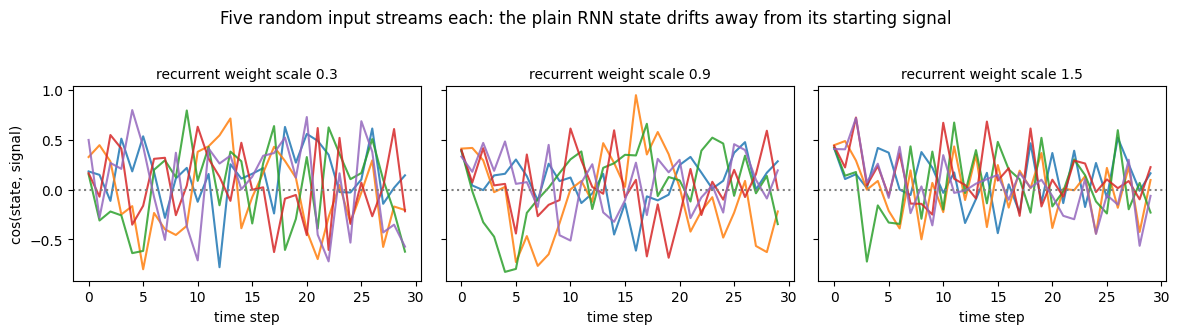

In [4]:
# Static sweep: how fast the plain RNN forgets, for three scales of the recurrent weights.
scales = [0.3, 0.9, 1.5]
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for a, s in zip(ax, scales):
    set_seed(0)
    W_s = torch.randn(H_DEMO, H_DEMO, device=device) * s
    for seed in range(5):
        a.plot(forgetting_trace(W_s, U_r, seed=seed), lw=1.5, alpha=0.85)
    a.axhline(0, color='gray', ls=':')
    a.set_title(f'recurrent weight scale {s}', fontsize=10); a.set_xlabel('time step')
ax[0].set_ylabel('cos(state, signal)')
fig.suptitle('Five random input streams each: the plain RNN state drifts away from its starting signal', y=1.03)
plt.tight_layout(); plt.show()


### Widget 1: how fast does the state forget?

Drag `scale` (the size of the recurrent weights) and `noise` (the size of the incoming inputs). With `noise` at zero the state still moves, because the recurrence alone rewrites it; with a small `scale` the similarity collapses towards zero even faster. There is no setting that keeps the curve near $1$ for long, which is the point.


In [5]:
def forgetting_demo(scale=0.9, noise=1.0, steps=30):
    set_seed(0)
    W_s = torch.randn(H_DEMO, H_DEMO, device=device) * scale
    fig, a = plt.subplots(figsize=(7, 3.4))
    for seed in range(5):
        a.plot(forgetting_trace(W_s, U_r, steps=steps, noise=noise, seed=seed), lw=1.5)
    a.axhline(0, color='gray', ls=':')
    a.set_ylim(-1.05, 1.05); a.set_xlabel('time step'); a.set_ylabel('cos(state, signal)')
    a.set_title(f'plain RNN, weight scale {scale:.2f}, input noise {noise:.1f}')
    plt.tight_layout(); plt.show()

interact(forgetting_demo,
         scale=FloatSlider(min=0.1, max=2.0, step=0.1, value=0.9),
         noise=FloatSlider(min=0.0, max=3.0, step=0.25, value=1.0),
         steps=IntSlider(min=10, max=100, step=10, value=30));


interactive(children=(FloatSlider(value=0.9, description='scale', max=2.0, min=0.1), FloatSlider(value=1.0, de…

### 1.b A recall task with an adjustable gap

To *measure* the problem we need a task whose only difficulty is the distance between the clue and the moment it is needed. We build the slide's sentence synthetically:

- the first token is one of $K = 8$ **key** symbols (`A` to `H`, the *France*),
- then come `gap` **filler** symbols drawn at random from four filler tokens (`w x y z`, the *...*),
- then a **query** symbol (`?`, the *fluent*),

and the target is the key. Every sequence has length `gap + 2`, and chance accuracy is $1/8$. The model is a recurrent layer of 64 units followed by a linear classifier on the final hidden state, trained with Adam (learning rate $10^{-3}$, gradients clipped to norm 1) on freshly generated batches of 128, and evaluated on 1,000 held-out sequences. The recurrent layer is a `kind` argument, so the same code trains a vanilla RNN now and the gated cells later.

One detail is worth flagging now and measuring in section 4. For the gated cells we add a positive bias to the gate that decides how much of the old state to keep (the LSTM's forget gate, the GRU's update gate), so that it starts *open*; PyTorch's default initialization starts it around $0.5$. This is the initialization recommended since Gers et al., ICANN 1999 and studied by Jozefowicz et al., ICML 2015. Ignore it for the vanilla RNN, which has no such gate.


In [6]:
# The recall task: key, `gap` fillers, query. Target = the key.
K_KEYS, N_FILL = 8, 4
D_IN = K_KEYS + N_FILL + 1                       # one-hot input size: keys + fillers + query
QUERY = K_KEYS + N_FILL
SYMBOLS = list('ABCDEFGH') + list('wxyz') + ['?']

def make_recall_batch(n, gap, generator=None):
    '''n one-hot sequences of length gap + 2: [key, gap fillers, query]. Returns
    (x: (n, gap+2, D_IN) on device, target keys: (n,) on device, raw tokens on cpu).'''
    key = torch.randint(0, K_KEYS, (n,), generator=generator)
    filler = torch.randint(K_KEYS, K_KEYS + N_FILL, (n, gap), generator=generator)
    toks = torch.cat([key[:, None], filler, torch.full((n, 1), QUERY)], dim=1)
    x = F.one_hot(toks, D_IN).float()
    return x.to(device), key.to(device), toks

class SeqClassifier(nn.Module):
    '''A recurrent layer (RNN, LSTM or GRU) and a linear read-out of the final hidden state.'''
    def __init__(self, kind, hidden=64, keep_bias=0.0):
        super().__init__()
        layer = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}[kind]
        self.rnn = layer(D_IN, hidden, batch_first=True)
        self.head = nn.Linear(hidden, K_KEYS)
        # Start the keep-gate open. PyTorch stores gate blocks stacked along dim 0:
        # LSTM order i, f, g, o and GRU order r, z, n, so block H:2H is the LSTM forget
        # gate and the GRU update gate (which multiplies h_{t-1} in PyTorch's convention).
        if keep_bias and kind in ('LSTM', 'GRU'):
            with torch.no_grad():
                self.rnn.bias_ih_l0[hidden:2 * hidden].fill_(keep_bias)
                self.rnn.bias_hh_l0[hidden:2 * hidden].zero_()

    def forward(self, x):
        out, _ = self.rnn(x)                     # out: (B, T, H)
        return self.head(out[:, -1])             # classify from the last hidden state

def train_recall(kind, gap, steps=800, lr=1e-3, batch=128, keep_bias=0.0, seed=0, eval_every=25):
    '''Train one SeqClassifier on the recall task at a fixed gap. Returns the model and a
    history with the loss at every step and held-out accuracy every `eval_every` steps.'''
    set_seed(seed)
    model = SeqClassifier(kind, keep_bias=keep_bias).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    g = torch.Generator().manual_seed(1234)      # the held-out set is the same for every model
    x_val, y_val, _ = make_recall_batch(1000, gap, g)
    hist = dict(loss=[], acc=[], eval_steps=[])
    for step in range(steps):
        x, y, _ = make_recall_batch(batch, gap)
        loss = F.cross_entropy(model(x), y)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # the previous lecture's fix for exploding gradients
        opt.step()
        hist['loss'].append(loss.item())
        if step % eval_every == 0 or step == steps - 1:
            with torch.no_grad():
                hist['acc'].append((model(x_val).argmax(1) == y_val).float().mean().item())
            hist['eval_steps'].append(step)
    return model, hist

x_ex, y_ex, toks_ex = make_recall_batch(3, 6, torch.Generator().manual_seed(0))
print('three example sequences at gap 6 (input tokens -> target):')
for row, y in zip(toks_ex.tolist(), y_ex.tolist()):
    print('  ', ' '.join(SYMBOLS[t] for t in row), ' -> ', SYMBOLS[y])
print(f'\ninput tensor shape {tuple(x_ex.shape)} = (batch, gap + 2, one-hot size)')
print(f'chance accuracy = 1/{K_KEYS} = {1 / K_KEYS:.3f}')


three example sequences at gap 6 (input tokens -> target):
   E w z z z z x ?  ->  E
   H z x y w z y ?  ->  H
   F w w w y x y ?  ->  F

input tensor shape (3, 8, 13) = (batch, gap + 2, one-hot size)
chance accuracy = 1/8 = 0.125


### 1.c The vanilla RNN versus the gap

We train the plain RNN once per gap, for the same number of steps, and record when (if ever) it first reaches 95% held-out accuracy. The histories are stored in `HIST` for the figures and widgets later on.


In [7]:
GAPS = [5, 10, 20, 40, 80]
HIST = {}                                        # (kind, gap) -> training history

def run_all_gaps(kind, keep_bias=0.0, steps=800):
    '''Train `kind` at every gap in GAPS, print a summary line per gap, keep the models.'''
    t_all = time.time()
    extra = f', keep-gate bias {keep_bias:g}' if keep_bias else ''
    print(f'{kind}: {steps} Adam steps per gap, learning rate 1e-3, batch 128, hidden 64{extra}')
    print(f'{"gap":>5s} {"final acc":>10s} {"steps to 95%":>13s} {"seconds":>8s}')
    models = {}
    for gap in GAPS:
        t0 = time.time()
        model, hist = train_recall(kind, gap, steps=steps, keep_bias=keep_bias)
        hist['seconds'] = time.time() - t0
        HIST[(kind, gap)] = hist
        models[gap] = model
        first = next((s for s, a in zip(hist['eval_steps'], hist['acc']) if a >= 0.95), None)
        print(f'{gap:5d} {hist["acc"][-1]:10.3f} {(str(first) if first is not None else "never"):>13s} {hist["seconds"]:8.1f}')
    print(f'total {time.time() - t_all:.1f} s')
    return models

RNN_MODELS = run_all_gaps('RNN')


RNN: 800 Adam steps per gap, learning rate 1e-3, batch 128, hidden 64
  gap  final acc  steps to 95%  seconds


    5      1.000           100      1.0


   10      1.000           175      0.7


   20      1.000           200      1.2


   40      0.114         never      2.2


   80      0.125         never      3.9
total 9.1 s


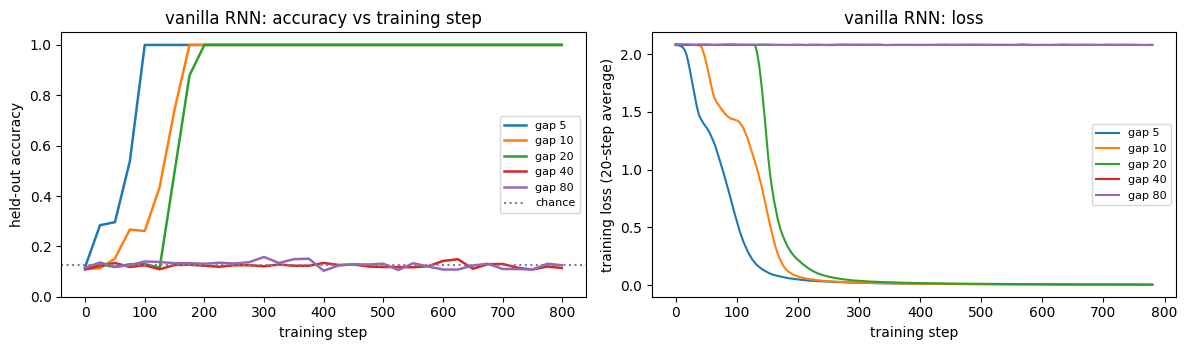

In [8]:
# Accuracy and loss curves of the vanilla RNN, one line per gap.
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for gap in GAPS:
    h = HIST[('RNN', gap)]
    ax[0].plot(h['eval_steps'], h['acc'], lw=1.8, label=f'gap {gap}')
    ax[1].plot(np.convolve(h['loss'], np.ones(20) / 20, mode='valid'), lw=1.5, label=f'gap {gap}')
ax[0].axhline(1 / K_KEYS, color='gray', ls=':', label='chance')
ax[0].set_xlabel('training step'); ax[0].set_ylabel('held-out accuracy'); ax[0].set_ylim(0, 1.05)
ax[0].set_title('vanilla RNN: accuracy vs training step'); ax[0].legend(fontsize=8)
ax[1].set_xlabel('training step'); ax[1].set_ylabel('training loss (20-step average)')
ax[1].set_title('vanilla RNN: loss'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


The three short gaps are learned, in 100, 175 and 200 steps, the cost already growing with the gap; at 40 and 80 the accuracy sits at chance for the whole run and the loss never leaves $\ln 8 \approx 2.08$. Nothing about the task changed except the distance between the key and the query. That is the long-term dependency problem as a number, and the rest of the lecture is about the architecture that removes it. We return to this table in section 8, where the LSTM and GRU rows are added.


## 2. The LSTM cell, gate by gate

The **Long Short-Term Memory** network was proposed by Hochreiter and Schmidhuber, *Neural Computation 1997*, as a solution to the long-term dependency problem. The slides describe it in four statements, which we take in order.

- On step $t$ there is a hidden state $h_t$ **and a cell state** $C_t$. The cell stores long-term information.
- The LSTM can **erase, write and read** information from the cell.
- Which information is erased, written or read is controlled by three corresponding **gates**. Each gate is a sigmoid layer followed by a pointwise multiplication, so every gate element lies in $[0, 1]$: open (1), closed (0), or somewhere in between.
- The gates are **dynamic**: their value is computed from the current context, not fixed.

All RNNs are a chain of repeating modules. In the vanilla RNN the repeating module is a single $\tanh$ layer. In the LSTM it contains **four interacting layers**: three sigmoid gates and one $\tanh$ candidate. Writing $[h_{t-1}, x_t]$ for the concatenation of the previous hidden state and the current input, the slides give:

$$f_t = \sigma\left(W_f \cdot [h_{t-1}, x_t] + b_f\right) \qquad \text{forget gate: what is kept from the previous cell state}$$
$$i_t = \sigma\left(W_i \cdot [h_{t-1}, x_t] + b_i\right) \qquad \text{input gate: which parts of the new content are written}$$
$$\tilde C_t = \tanh\left(W_C \cdot [h_{t-1}, x_t] + b_C\right) \qquad \text{cell content: the new content itself}$$
$$C_t = f_t * C_{t-1} + i_t * \tilde C_t \qquad \text{cell state: erase ("forget") some, write ("input") some}$$
$$o_t = \sigma\left(W_o \cdot [h_{t-1}, x_t] + b_o\right) \qquad \text{output gate: what parts of the cell are output}$$
$$h_t = o_t * \tanh(C_t) \qquad \text{hidden state: read ("output") some content from the cell}$$

Note where each nonlinearity goes: **sigmoid on the three gates, tanh on the candidate content, and tanh again on the cell when reading it out**. One slide caption calls the input gate the one that "decides what information to throw away"; the equations and the cell update make clear that it is $f_t$ that throws away and $i_t$ that lets new content in, and we follow the equations.

### 2.a From scratch, batched

We write the cell exactly as the equations above, for a batch of inputs, with the four weight matrices in the deck's concatenated form $W_* \in \mathbb{R}^{H \times (H + D)}$ acting on $[h_{t-1}, x_t]$. A second function runs it over a whole sequence and keeps every gate value, so we can look inside later. The `detach_h` switch is used in section 4 to isolate the cell-state path.


In [9]:
def init_lstm_params(D, H, seed=0, forget_bias=0.0):
    '''Deck-style LSTM parameters: W_f, W_i, W_C, W_o of shape (H, H + D) acting on
    [h_{t-1}, x_t], and biases b_f, b_i, b_C, b_o of shape (H,). All on `device`.'''
    g = torch.Generator().manual_seed(seed)
    p = {}
    for name in ('Wf', 'Wi', 'WC', 'Wo'):
        p[name] = (torch.randn(H, H + D, generator=g) / math.sqrt(H + D)).to(device)
    for name in ('bf', 'bi', 'bC', 'bo'):
        p[name] = torch.zeros(H, device=device)
    p['bf'] = p['bf'] + forget_bias              # a positive value starts the forget gate open
    return p

def lstm_step(p, x, h, C, detach_h=False):
    '''One LSTM step for a batch. x: (B, D); h, C: (B, H). Returns h_t, C_t and the gates.
    With detach_h=True the gates and candidate see a detached h_{t-1}, so that the only
    differentiable route from C_{t-1} to C_t is the forget-gate multiplication.'''
    h_in = h.detach() if detach_h else h
    z = torch.cat([h_in, x], dim=1)                          # [h_{t-1}, x_t]: (B, H + D)
    f = torch.sigmoid(z @ p['Wf'].T + p['bf'])               # forget gate, in [0, 1]
    i = torch.sigmoid(z @ p['Wi'].T + p['bi'])               # input gate, in [0, 1]
    C_tilde = torch.tanh(z @ p['WC'].T + p['bC'])            # candidate content, in [-1, 1]
    C_new = f * C + i * C_tilde                              # erase some, write some
    o = torch.sigmoid(z @ p['Wo'].T + p['bo'])               # output gate, in [0, 1]
    h_new = o * torch.tanh(C_new)                            # read some of the cell out
    return h_new, C_new, dict(f=f, i=i, o=o, C_tilde=C_tilde)

def lstm_forward(p, X, h0=None, C0=None, detach_h=False):
    '''Run lstm_step over X: (B, T, D). Returns h: (B, T, H), C: (B, T, H) and a dict of
    gate tensors of shape (B, T, H).'''
    B, T, _ = X.shape
    H = p['bf'].numel()
    h = torch.zeros(B, H, device=device) if h0 is None else h0
    C = torch.zeros(B, H, device=device) if C0 is None else C0
    hs, Cs, gates = [], [], dict(f=[], i=[], o=[], C_tilde=[])
    for t in range(T):
        h, C, g = lstm_step(p, X[:, t], h, C, detach_h)
        hs.append(h); Cs.append(C)
        for k in gates:
            gates[k].append(g[k])
    return torch.stack(hs, 1), torch.stack(Cs, 1), {k: torch.stack(v, 1) for k, v in gates.items()}

# One step on a random batch: every gate lies in [0, 1], the candidate in [-1, 1].
H, D = 8, 4
p_demo = init_lstm_params(D, H, seed=0)
x = torch.randn(5, D, device=device)
h, C, gates = lstm_step(p_demo, x, torch.zeros(5, H, device=device), torch.zeros(5, H, device=device))
print(f'h_t shape {tuple(h.shape)}, C_t shape {tuple(C.shape)}')
for name, v in gates.items():
    print(f'  {name:8s} range [{v.min().item():+.3f}, {v.max().item():+.3f}]')
print('\nthe three gates lie in [0, 1]; the candidate content lies in [-1, 1]')


h_t shape (5, 8), C_t shape (5, 8)
  f        range [+0.060, +0.918]
  i        range [+0.257, +0.757]
  o        range [+0.106, +0.776]
  C_tilde  range [-0.919, +0.781]

the three gates lie in [0, 1]; the candidate content lies in [-1, 1]


### 2.b The same cell in PyTorch, and the weight layout

`nn.LSTMCell` and `nn.LSTM` implement the same equations with a different bookkeeping. PyTorch keeps the input and recurrent weights separate, `weight_ih` of shape $(4H, D)$ and `weight_hh` of shape $(4H, H)$, stacks the four blocks in the order **$i, f, g, o$** (where $g$ is the candidate $\tilde C$), and carries two bias vectors, `bias_ih` and `bias_hh`, whose sum plays the role of the deck's single bias. The deck's $W_f \cdot [h_{t-1}, x_t]$ is therefore PyTorch's `weight_hh[H:2H] @ h + weight_ih[H:2H] @ x`. The two functions below map the parameters in both directions, and the asserts confirm the map is exact for a single step and for a whole sequence.


In [10]:
def _w(module, name):
    '''Fetch a weight from nn.LSTMCell / nn.GRUCell (`weight_ih`) or nn.LSTM / nn.GRU (`weight_ih_l0`).'''
    return getattr(module, name + '_l0') if hasattr(module, name + '_l0') else getattr(module, name)

def load_into_torch_lstm(p, module):
    '''Copy deck-style parameters into an nn.LSTMCell or nn.LSTM. PyTorch block order: i, f, g, o.'''
    H = p['bf'].numel()
    order = ['Wi', 'Wf', 'WC', 'Wo']
    with torch.no_grad():
        _w(module, 'weight_hh').copy_(torch.cat([p[k][:, :H] for k in order]))     # h part: columns :H
        _w(module, 'weight_ih').copy_(torch.cat([p[k][:, H:] for k in order]))     # x part: columns H:
        _w(module, 'bias_ih').copy_(torch.cat([p[k] for k in ('bi', 'bf', 'bC', 'bo')]))
        _w(module, 'bias_hh').zero_()

def params_from_torch_lstm(module):
    '''The inverse map: deck-style parameters from an nn.LSTMCell or nn.LSTM (layer 0).'''
    W_ih, W_hh = _w(module, 'weight_ih').detach(), _w(module, 'weight_hh').detach()
    b = (_w(module, 'bias_ih') + _w(module, 'bias_hh')).detach()   # the two biases only ever appear summed
    i_h, f_h, g_h, o_h = W_hh.chunk(4); i_x, f_x, g_x, o_x = W_ih.chunk(4)
    b_i, b_f, b_g, b_o = b.chunk(4)
    return dict(Wf=torch.cat([f_h, f_x], 1), Wi=torch.cat([i_h, i_x], 1),
                WC=torch.cat([g_h, g_x], 1), Wo=torch.cat([o_h, o_x], 1),
                bf=b_f, bi=b_i, bC=b_g, bo=b_o)

# 1. one step: ours == nn.LSTMCell after mapping our weights across
set_seed(0)
p_chk = init_lstm_params(D, H, seed=1, forget_bias=0.5)
ref_cell = nn.LSTMCell(D, H).to(device)
load_into_torch_lstm(p_chk, ref_cell)
x = torch.randn(3, D, device=device); h0 = torch.randn(3, H, device=device); C0 = torch.randn(3, H, device=device)
h_ours, C_ours, _ = lstm_step(p_chk, x, h0, C0)
h_ref, C_ref = ref_cell(x, (h0, C0))
assert torch.allclose(h_ours, h_ref, atol=1e-6) and torch.allclose(C_ours, C_ref, atol=1e-6)
print(f'one step   : ours vs nn.LSTMCell   max |diff| h = {(h_ours - h_ref).abs().max():.2e}, C = {(C_ours - C_ref).abs().max():.2e}')

# 2. a whole sequence: ours == nn.LSTM (batch_first), and the reverse map round-trips
ref_seq = nn.LSTM(D, H, batch_first=True).to(device)
load_into_torch_lstm(p_chk, ref_seq)
X = torch.randn(3, 12, D, device=device)
h_seq, C_seq, _ = lstm_forward(p_chk, X)
out_ref, (hn_ref, cn_ref) = ref_seq(X)
assert torch.allclose(h_seq, out_ref, atol=1e-6)
assert torch.allclose(C_seq[:, -1], cn_ref[0], atol=1e-6)
print(f'12 steps   : ours vs nn.LSTM       max |diff| h = {(h_seq - out_ref).abs().max():.2e}, final C = {(C_seq[:, -1] - cn_ref[0]).abs().max():.2e}')

p_back = params_from_torch_lstm(ref_seq)
assert all(torch.allclose(p_back[k], p_chk[k]) for k in p_chk)
print('round trip : deck layout -> PyTorch (i, f, g, o) -> deck layout recovers every matrix exactly')


one step   : ours vs nn.LSTMCell   max |diff| h = 5.96e-08, C = 7.45e-08
12 steps   : ours vs nn.LSTM       max |diff| h = 1.19e-07, final C = 6.71e-08
round trip : deck layout -> PyTorch (i, f, g, o) -> deck layout recovers every matrix exactly


### 2.c The LSTM versus the gap

Now the same recall experiment with `nn.LSTM` in place of `nn.RNN`, everything else unchanged. The forget-gate bias is set to $+5$, so $f_t = \sigma(5) \approx 0.993$ at initialization: the cell starts by keeping almost everything, and training decides what to forget. Section 4.d measures what happens with PyTorch's default instead.


In [11]:
KEEP_BIAS = 5.0
print(f'initial keep-gate value sigma({KEEP_BIAS:g}) = {torch.sigmoid(torch.tensor(KEEP_BIAS)).item():.4f}\n')
LSTM_MODELS = run_all_gaps('LSTM', keep_bias=KEEP_BIAS)


initial keep-gate value sigma(5) = 0.9933

LSTM: 800 Adam steps per gap, learning rate 1e-3, batch 128, hidden 64, keep-gate bias 5
  gap  final acc  steps to 95%  seconds


    5      1.000            50      1.4


   10      1.000            75      2.1


   20      1.000            50      3.6


   40      1.000            75      6.3


   80      1.000            50     13.2
total 26.7 s


Every gap that defeated the vanilla RNN is solved, and in 50 to 75 steps regardless of the gap: with the highway open from the start, the distance between the key and the query costs the LSTM nothing. The comparison figure comes in section 8; first we open the trained model and look at what its gates are doing.

### 2.d Inside a trained LSTM: the gates over a sequence

The slides insist the gates are **dynamic**, "computed based on current context". With `params_from_torch_lstm` we can run the trained gap-20 model through our own `lstm_forward`, check that it reproduces `nn.LSTM`'s output exactly, and read off every gate and the cell state at every step. From the equations one might expect an input gate that opens when the key arrives and shuts during the fillers, and a forget gate that stays open across the gap. We print the mean gate values at the key step, during the fillers and at the query, together with the size of what the cell actually writes, $|i_t * \tilde C_t|$, and the size of the cell and hidden states.


In [12]:
VIS_GAP = 20
p_trained = params_from_torch_lstm(LSTM_MODELS[VIS_GAP].rnn)
x_vis, y_vis, toks_vis = make_recall_batch(8, VIS_GAP, torch.Generator().manual_seed(7))
with torch.no_grad():
    h_vis, C_vis, g_vis = lstm_forward(p_trained, x_vis)
    out_ref, _ = LSTM_MODELS[VIS_GAP].rnn(x_vis)
    pred = LSTM_MODELS[VIS_GAP].head(h_vis[:, -1]).argmax(1)
assert torch.allclose(h_vis, out_ref, atol=1e-5), 'our forward pass disagrees with nn.LSTM'
print(f'trained gap-{VIS_GAP} LSTM reproduced by lstm_forward: max |diff| = {(h_vis - out_ref).abs().max():.2e}')
print(f'predictions on the 8 sequences: {[SYMBOLS[k] for k in pred.tolist()]}, targets {[SYMBOLS[k] for k in y_vis.tolist()]}')

GATES_NP = {k: v.detach().cpu().numpy() for k, v in g_vis.items()}
GATES_NP['C'] = C_vis.detach().cpu().numpy(); GATES_NP['h'] = h_vis.detach().cpu().numpy()
TOKS_VIS = [[SYMBOLS[t] for t in row] for row in toks_vis.tolist()]

# The measured claim: do the gates react to the context? Means over the 8 sequences and 64 units.
write_np = np.abs(GATES_NP['i'] * GATES_NP['C_tilde'])          # what is actually written into the cell: |i_t * C~_t|
rows = [('forget gate f_t', GATES_NP['f']), ('input gate i_t', GATES_NP['i']), ('output gate o_t', GATES_NP['o']),
        ('write |i_t * C~_t|', write_np), ('cell state |C_t|', np.abs(GATES_NP['C'])), ('hidden state |h_t|', np.abs(GATES_NP['h']))]
print(f'\n{"mean over units":22s} {"key step":>9s} {"fillers":>9s} {"query":>9s}')
for name, arr in rows:
    print(f'{name:22s} {arr[:, 0].mean():9.3f} {arr[:, 1:-1].mean():9.3f} {arr[:, -1].mean():9.3f}')


trained gap-20 LSTM reproduced by lstm_forward: max |diff| = 1.76e-06
predictions on the 8 sequences: ['H', 'E', 'B', 'G', 'D', 'D', 'H', 'H'], targets ['H', 'E', 'B', 'G', 'D', 'D', 'H', 'H']

mean over units         key step   fillers     query
forget gate f_t            0.994     0.995     0.994
input gate i_t             0.527     0.677     0.673
output gate o_t            0.554     0.826     0.852
write |i_t * C~_t|         0.056     0.272     0.368
cell state |C_t|           0.056     2.029     5.347
hidden state |h_t|         0.031     0.583     0.845


Three things stand out. The forget gate is $0.99$ at every step: the bias we set at initialization was never undone, because nothing in this task ever needs to be forgotten, and the cell integrates whatever it is fed, $|C_t|$ growing from $0.06$ at the key to $2.0$ during the fillers and $5.3$ at the query. The write $|i_t * \tilde C_t|$ is *smaller* at the key ($0.06$) than during the fillers ($0.27$): the network does not store the key with one large write and then close the door. It stores a small pattern at step 0, keeps it ($0.995^{20} \approx 0.9$ of it survives to the query), and reads it out against a filler background that does not erase it. And the gates do depend on context, which is the slide's point: the output gate averages $0.55$ at the key against $0.83$ during the fillers, the input gate $0.53$ against $0.68$. What the network learned is not the tidy picture the equations suggest, an input gate that opens for the key and shuts for the gap, because with the highway open there was no pressure to learn it. The heatmaps show the per-unit detail.


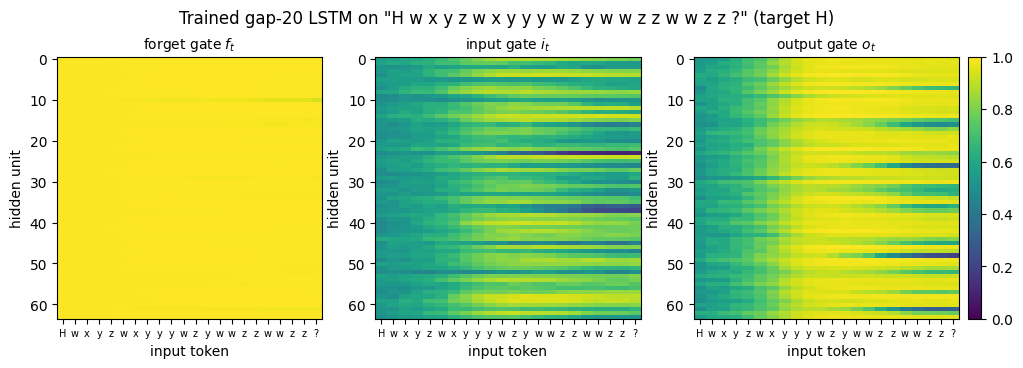

In [13]:
# Static figure: the three gates over one sequence, one row per hidden unit.
def gate_heatmap(a, arr, title, cmap='viridis', vmin=0, vmax=1, toks=None):
    im = a.imshow(arr.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    a.set_title(title, fontsize=10); a.set_ylabel('hidden unit')
    if toks is not None:
        a.set_xticks(range(len(toks))); a.set_xticklabels(toks, fontsize=7)
    return im

ex = 0
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for a, name, label in zip(ax, ['f', 'i', 'o'], ['forget gate $f_t$', 'input gate $i_t$', 'output gate $o_t$']):
    im = gate_heatmap(a, GATES_NP[name][ex], label, toks=TOKS_VIS[ex])
    a.set_xlabel('input token')
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
fig.suptitle(f'Trained gap-{VIS_GAP} LSTM on "{" ".join(TOKS_VIS[ex])}" (target {SYMBOLS[y_vis[ex].item()]})', y=1.02)
plt.show()


### Widget 2: gate activations over a sequence

Pick a `quantity` and an `example`. `f` is a flat $0.99$. `i` and `o` vary from unit to unit and from step to step, and in `o` the first column (the key) is visibly darker than the fillers. `C` shows the integration: most units drift steadily in one direction across the fillers, and `h` follows through the output gate and $\tanh$. Examples 0, 6 and 7 share the key H, examples 4 and 5 the key D.


In [14]:
def gates_demo(quantity='f', example=0):
    arr = GATES_NP[quantity][example]
    signed = quantity in ('C', 'h', 'C_tilde')
    names = dict(f='forget gate $f_t$', i='input gate $i_t$', o='output gate $o_t$',
                 C_tilde='candidate $\\tilde C_t$', C='cell state $C_t$', h='hidden state $h_t$')
    fig, a = plt.subplots(figsize=(8, 3.6))
    lim = float(np.abs(arr).max()) if signed else 1.0
    im = gate_heatmap(a, arr, f'{names[quantity]}, example {example} (target {SYMBOLS[y_vis[example].item()]})',
                      cmap='coolwarm' if signed else 'viridis', vmin=-lim if signed else 0, vmax=lim, toks=TOKS_VIS[example])
    a.set_xlabel('input token'); fig.colorbar(im, ax=a, fraction=0.03, pad=0.02)
    plt.tight_layout(); plt.show()

interact(gates_demo,
         quantity=Dropdown(options=['f', 'i', 'o', 'C_tilde', 'C', 'h'], value='f'),
         example=IntSlider(min=0, max=7, step=1, value=0));


interactive(children=(Dropdown(description='quantity', options=('f', 'i', 'o', 'C_tilde', 'C', 'h'), value='f'…

## 3. The constant error carousel

The slides pose two thought experiments about the cell update

$$C_t = f_t * C_{t-1} + i_t * \tilde C_t .$$

> "What can you tell about cell state $C_t$, if forget gate is set to 1 and input gate set to 0?"

Setting $f_t = 1$ and $i_t = 0$ gives $C_t = C_{t-1}$ exactly, whatever the candidate says. The information in that cell is **preserved indefinitely**. Hochreiter and Schmidhuber called this loop the *constant error carousel*: a unit whose self-connection has weight exactly $1$, so that both the activation and the error flowing back through it stay constant. It is the mechanism the whole architecture is built around, and the reason the cell state is drawn as a straight line running along the top of the module.

> "What happens if you fix input gate to all 1s, forget gate to all 0s, output gate to all 1s?"

Then $C_t = \tilde C_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$ and $h_t = \tanh(C_t)$: the cell forgets everything, writes the fresh content, and exposes it. That is **almost** a standard RNN. The slide's "why almost?" has a one-word answer, **tanh**: the standard RNN computes $h_t = \tanh(W \cdot [h_{t-1}, x_t] + b)$, while this LSTM applies $\tanh$ a second time when reading the cell out, $h_t = \tanh(\tanh(\cdot))$. Both statements are checked below on the real `lstm_step` of section 2, not on hand-written arithmetic: the gate biases are pushed to $\pm 40$, which saturates the sigmoids to exactly $0$ and $1$ in float32 whatever the input, and the second check compares the forced cell against `nn.RNNCell` loaded with the candidate's weights $W_C$ and bias $b_C$.


In [15]:
# 1. f = 1, i = 0 inside the real cell: 1000 random inputs, and the cell state is preserved bit for bit.
# Biases of +40 / -40 saturate the sigmoids to exactly 1 and 0 in float32, whatever [h, x] says.
set_seed(0)
p_cec = init_lstm_params(D, H, seed=2)
p_cec['bf'] = p_cec['bf'] + 40.0                 # forget gate pinned open
p_cec['bi'] = p_cec['bi'] - 40.0                 # input gate pinned shut
C_start = torch.randn(1, H, device=device)
X_cec = torch.randn(1, 1000, D, device=device)   # whatever the candidate says, it is ignored
_, C_seq_cec, g_cec = lstm_forward(p_cec, X_cec, torch.zeros(1, H, device=device), C_start)
print(f'gates over 1000 steps of lstm_step: f min {g_cec["f"].min():.6f}, i max {g_cec["i"].max():.1e}')
assert torch.equal(C_seq_cec[:, -1], C_start), 'the cell state changed despite f = 1, i = 0'
print(f'after 1000 steps with f = 1, i = 0:  max |C_t - C_0| = {(C_seq_cec[:, -1] - C_start).abs().max():.1e}  (preserved indefinitely)')

# 2. i = 1, f = 0, o = 1: the same cell becomes tanh(tanh(W_C [h, x] + b_C)), a standard RNN with an extra tanh.
# The reference is nn.RNNCell loaded with the candidate's weights W_C and bias b_C.
p_car = init_lstm_params(D, H, seed=2)
p_car['bf'] = p_car['bf'] - 40.0; p_car['bi'] = p_car['bi'] + 40.0; p_car['bo'] = p_car['bo'] + 40.0
x = torch.randn(4, D, device=device); h_prev = torch.randn(4, H, device=device); C_prev = torch.randn(4, H, device=device)
h_lstm, C_lstm, g_car = lstm_step(p_car, x, h_prev, C_prev)
ref = nn.RNNCell(D, H).to(device)                # h = tanh(x W_ih^T + h W_hh^T + b_ih + b_hh)
with torch.no_grad():
    ref.weight_hh.copy_(p_car['WC'][:, :H]); ref.weight_ih.copy_(p_car['WC'][:, H:])   # W_C acts on [h, x]
    ref.bias_ih.copy_(p_car['bC']); ref.bias_hh.zero_()
h_rnn = ref(x, h_prev)
print(f'\nforced gates: f max {g_car["f"].max():.1e}, i min {g_car["i"].min():.6f}, o min {g_car["o"].min():.6f}')
assert torch.allclose(h_lstm, torch.tanh(h_rnn), atol=1e-6), 'the forced LSTM is not tanh(RNNCell(x, h))'
print(f'with i = 1, f = 0, o = 1:  max |h_LSTM - tanh(RNNCell(x, h))| = {(h_lstm - torch.tanh(h_rnn)).abs().max():.1e}')
print(f'                           max |h_LSTM - RNNCell(x, h)|       = {(h_lstm - h_rnn).abs().max():.3f}  <- the extra tanh is the "almost"')


gates over 1000 steps of lstm_step: f min 1.000000, i max 5.1e-17
after 1000 steps with f = 1, i = 0:  max |C_t - C_0| = 0.0e+00  (preserved indefinitely)

forced gates: f max 1.7e-17, i min 1.000000, o min 1.000000
with i = 1, f = 0, o = 1:  max |h_LSTM - tanh(RNNCell(x, h))| = 1.2e-07
                           max |h_LSTM - RNNCell(x, h)|       = 0.168  <- the extra tanh is the "almost"


## 4. The gradient highway

> "Gradient at $C_t$ passed on to $C_{t-1}$ unaffected by any other operations, but for forget gate; why does this not matter?"

### 4.a $\partial C_T / \partial C_0$ is the product of the forget gates

Along the cell state path the update is **additive**, $C_t = f_t * C_{t-1} + i_t * \tilde C_t$, so

$$\frac{\partial C_t}{\partial C_{t-1}} = \mathrm{diag}(f_t) \qquad\text{and}\qquad \frac{\partial C_T}{\partial C_0} = \prod_{t=1}^{T} \mathrm{diag}(f_t) = \mathrm{diag}\Big(\prod_{t=1}^{T} f_t\Big).$$

There is no weight matrix on this path and no $\tanh'$ factor: nothing multiplies the gradient except the gates themselves. This is the **gradient highway** of the slide. Strictly, the cell state also reaches the next step indirectly, through $h_t = o_t * \tanh(C_t)$ and from there into the next step's gates and candidate. We check both: first the highway alone, by computing the gates from a detached $h_{t-1}$ so that the only differentiable route is the chain of forget gates, and then the full Jacobian, for several initial forget biases, to see how large the indirect terms are.


In [16]:
def jacobian_wrt(out, inp):
    '''Full Jacobian d out / d inp for a single example (out: (1, H_out), inp: (1, H_in)),
    one backward pass per output unit.'''
    rows = []
    for k in range(out.shape[1]):
        g, = torch.autograd.grad(out[0, k], inp, retain_graph=True)
        rows.append(g[0])
    return torch.stack(rows)

set_seed(0)
H_S, D_S, T_S = 16, 6, 12
p_hw = init_lstm_params(D_S, H_S, seed=3, forget_bias=1.0)
X_hw = torch.randn(1, T_S, D_S, device=device)
h0_hw = torch.zeros(1, H_S, device=device)
C0_hw = torch.randn(1, H_S, device=device, requires_grad=True)

# highway only: gates see a detached h, so C_0 reaches C_T only through the forget gates
_, C_seq, gates = lstm_forward(p_hw, X_hw, h0_hw, C0_hw, detach_h=True)
J_cell = jacobian_wrt(C_seq[:, -1], C0_hw)
f_prod = gates['f'][0].prod(dim=0)                         # prod_t f_t, elementwise
assert torch.allclose(J_cell, torch.diag(f_prod), atol=1e-6), 'dC_T/dC_0 is not the product of forget gates'
print(f'cell path only: dC_T/dC_0 == diag(prod_t f_t)      max |diff| = {(J_cell - torch.diag(f_prod)).abs().max():.1e}')
print(f'  first four forget products over {T_S} steps: {[round(v, 4) for v in f_prod[:4].tolist()]}')

# full LSTM: the indirect route through h_t adds terms. How big are they, for several forget biases?
print(f'\nfull LSTM Jacobian dC_T/dC_0 over {T_S} steps, random weights, by initial forget bias:')
print(f'{"bias":>5s} {"f ~":>6s} {"|diag|":>8s} {"|off-diag|":>11s} {"max |diag - prod f|":>20s}')
for b in (0.0, 1.0, 2.0, 3.0, 5.0):
    p_b = init_lstm_params(D_S, H_S, seed=3, forget_bias=b)
    _, C_full, gates_full = lstm_forward(p_b, X_hw, h0_hw, C0_hw)
    J_full = jacobian_wrt(C_full[:, -1], C0_hw)
    f_prod_full = gates_full['f'][0].prod(dim=0)
    diag_err = (torch.diag(J_full) - f_prod_full).abs().max().item()
    off = (J_full - torch.diag(torch.diag(J_full))).norm().item()
    print(f'{b:5.0f} {torch.sigmoid(torch.tensor(b)).item():6.2f} {torch.diag(J_full).norm().item():8.3f} {off:11.3f} {diag_err:20.1e}')


cell path only: dC_T/dC_0 == diag(prod_t f_t)      max |diff| = 7.5e-09
  first four forget products over 12 steps: [0.0134, 0.0258, 0.0409, 0.03]

full LSTM Jacobian dC_T/dC_0 over 12 steps, random weights, by initial forget bias:
 bias    f ~   |diag|  |off-diag|  max |diag - prod f|
    0   0.50    0.004       0.017              2.2e-03
    1   0.73    0.147       0.433              4.4e-02
    2   0.88    1.080       1.960              1.9e-01
    3   0.95    2.471       3.694              3.9e-01
    5   0.99    4.000       5.443              5.6e-01


The highway-only Jacobian is exactly $\mathrm{diag}(\prod_t f_t)$, to floating-point precision. The full Jacobian is not: with random weights of the usual scale the indirect route through $h_t$ contributes off-diagonal terms whose norm is comparable to, here larger than, the diagonal's, at every forget bias, and it perturbs the diagonal itself. That is worth knowing, because the slide's picture is easily over-read as "the cell path is all there is". The right reading is different. The highway is a *guaranteed* term, $\prod_t f_t$ on every diagonal entry, that no weight matrix and no $\tanh'$ can shrink, and whose size the forget gates set directly: the diagonal norm goes from $0.004$ at bias $0$ to $4.0$ at bias $5$ over twelve steps. The indirect terms are products of the same kind the vanilla RNN is made of, and they can vanish or explode; the difference is that they are no longer the only route.


### 4.b Compared with the vanilla RNN's Jacobian product

For the plain RNN the previous lecture derived

$$\frac{\partial h_T}{\partial h_0} = \prod_{t=1}^{T} \mathrm{diag}(1 - h_t^2)\, W ,$$

a product of $T$ matrices, each with the same $W$ inside and a $\tanh'$ factor at most $1$. We build the RNN from scratch too, confirm the formula against autograd, and then compare how far back a gradient reaches in the two architectures: the norm of $\partial (v \cdot s_T) / \partial s_0$ for a fixed random direction $v$, where $s$ is $h$ for the RNN and $C$ for the LSTM, as $T$ grows. For the LSTM the full model is differentiated, indirect route included.


RNN: dh_T/dh_0 == prod_t diag(1 - h_t^2) W    max |diff| = 4.2e-09
     norm of dh_T/dh_0 over 12 steps = 0.0348     LSTM highway (forget bias 1) over 12 steps = 0.1049



LSTM: gradient norm reaching C_0 after T steps, by forget bias; the highway alone would give sigma(b)^T
 bias    f ~       T=1      T=30      T=60  sigma(b)^60
    0   0.50  5.28e-01  1.93e-06  9.27e-10     8.67e-19
    2   0.88  8.85e-01  9.77e-01  1.20e+00     4.93e-04
    5   0.99  9.93e-01  2.79e+00  7.37e+00     6.68e-01


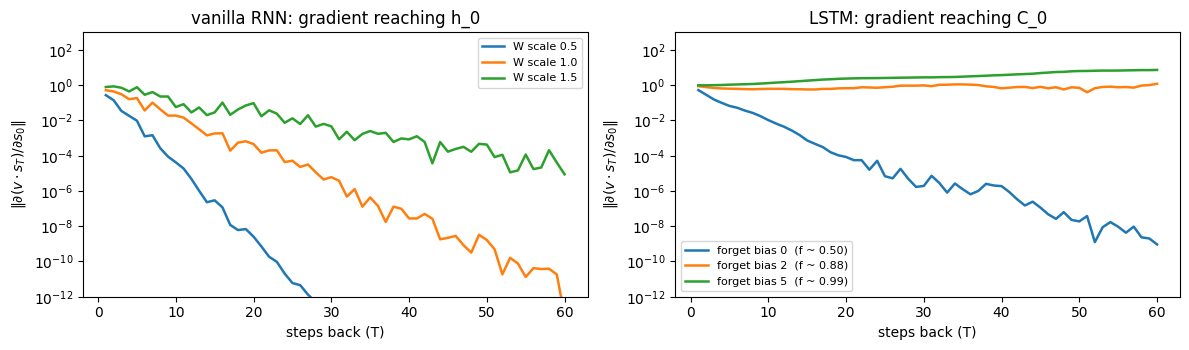

In [17]:
def init_rnn_params(D, H, seed=0, scale=1.0):
    '''Vanilla tanh RNN: h_t = tanh(x_t W_xh^T + h_{t-1} W_hh^T + b). `scale` sets the spectral
    size of W_hh (randn / sqrt(H) has spectral radius about 1).'''
    g = torch.Generator().manual_seed(seed)
    return dict(W_xh=(torch.randn(H, D, generator=g) / math.sqrt(D)).to(device),
                W_hh=(torch.randn(H, H, generator=g) * scale / math.sqrt(H)).to(device),
                b=torch.zeros(H, device=device))

def rnn_step(p, x, h):
    return torch.tanh(x @ p['W_xh'].T + h @ p['W_hh'].T + p['b'])

def rnn_forward(p, X, h0):
    '''Run rnn_step over X: (B, T, D). Returns h: (B, T, H).'''
    hs, h = [], h0
    for t in range(X.shape[1]):
        h = rnn_step(p, X[:, t], h); hs.append(h)
    return torch.stack(hs, 1)

# The product-of-Jacobians formula against autograd.
p_rnn = init_rnn_params(D_S, H_S, seed=3, scale=1.0)
h0_rnn = torch.randn(1, H_S, device=device, requires_grad=True)
h_seq = rnn_forward(p_rnn, X_hw, h0_rnn)
J_auto = jacobian_wrt(h_seq[:, -1], h0_rnn)
J_manual = torch.eye(H_S, device=device)
for t in range(T_S):                                        # J = J_T ... J_2 J_1
    J_manual = torch.diag(1 - h_seq[0, t] ** 2) @ p_rnn['W_hh'] @ J_manual
assert torch.allclose(J_auto, J_manual, atol=1e-5), 'RNN Jacobian product does not match autograd'
print(f'RNN: dh_T/dh_0 == prod_t diag(1 - h_t^2) W    max |diff| = {(J_auto - J_manual).abs().max():.1e}')
print(f'     norm of dh_T/dh_0 over {T_S} steps = {J_auto.norm():.4f}     LSTM highway (forget bias 1) over {T_S} steps = {torch.diag(f_prod).norm():.4f}')

def reach_curve(kind, T=60, scale=1.0, forget_bias=0.0, H=32, D=8, seed=0):
    '''||d(v . s_T) / d s_0|| for T = 1..T with a fixed random unit v; s = h (RNN) or C (LSTM).'''
    set_seed(seed)
    X = torch.randn(1, T, D, device=device)
    v = torch.randn(H, device=device); v = v / v.norm()
    s0 = (torch.randn(1, H, device=device) * 0.5).requires_grad_(True)
    if kind == 'RNN':
        states = rnn_forward(init_rnn_params(D, H, seed, scale), X, s0)
    else:
        _, states, _ = lstm_forward(init_lstm_params(D, H, seed, forget_bias), X, torch.zeros(1, H, device=device), s0)
    norms = []
    for t in range(T):
        g, = torch.autograd.grad(states[0, t] @ v, s0, retain_graph=True)
        norms.append(g.norm().item())
    return norms

# Static sweep: how far back the gradient reaches.
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for s in (0.5, 1.0, 1.5):
    ax[0].semilogy(range(1, 61), reach_curve('RNN', scale=s), lw=1.8, label=f'W scale {s}')
REACH_LSTM = {b: reach_curve('LSTM', forget_bias=b) for b in (0.0, 2.0, 5.0)}
print(f'\nLSTM: gradient norm reaching C_0 after T steps, by forget bias; the highway alone would give sigma(b)^T')
print(f'{"bias":>5s} {"f ~":>6s} {"T=1":>9s} {"T=30":>9s} {"T=60":>9s} {"sigma(b)^60":>12s}')
for b, rc in REACH_LSTM.items():
    f0 = torch.sigmoid(torch.tensor(b)).item()
    print(f'{b:5.0f} {f0:6.2f} {rc[0]:9.2e} {rc[29]:9.2e} {rc[59]:9.2e} {f0 ** 60:12.2e}')
for b, rc in REACH_LSTM.items():
    ax[1].semilogy(range(1, 61), rc, lw=1.8, label=f'forget bias {b:g}  (f ~ {torch.sigmoid(torch.tensor(b)).item():.2f})')
for a, title in zip(ax, ['vanilla RNN: gradient reaching h_0', 'LSTM: gradient reaching C_0']):
    a.set_xlabel('steps back (T)'); a.set_ylabel(r'$\|\partial (v\cdot s_T)/\partial s_0\|$'); a.set_title(title); a.legend(fontsize=8)
    a.set_ylim(1e-12, 1e3)
plt.tight_layout(); plt.show()


The RNN's curve is a straight line on the log axis: geometric decay (or growth) set by $W$, with no way to tune it per unit or per step. The LSTM's curve has a product of *gates* in it, and their typical value is a bias away. With the forget bias at $0$ the gates sit around $0.5$, the highway loses half its signal per step, and the gradient reaching $C_0$ is about $10^{-9}$ after sixty steps (above the highway's own $0.5^{60} \approx 10^{-18}$ only because of the indirect route, but vanished all the same). At bias $5$ the gradient does not decay over sixty steps at all; it in fact *grows*, from $0.99$ after one step to $2.8$ after thirty and $7.4$ after sixty, a factor of about $7$. The highway alone cannot do that: $\sigma(5)^{60} = 0.67$, the dotted reference drawn in the widget below, and a product of forget gates is never larger than $1$. The growth comes from the indirect route through $h_t$, the off-diagonal terms that section 4.a measured as larger than the diagonal; at bias $2$ the same route holds the gradient at $1.2$ after sixty steps where the highway's own $\sigma(2)^{60} \approx 5 \times 10^{-4}$ would have nearly vanished. What the forget bias sets is the guaranteed floor; once that floor is high enough, the indirect terms add to it instead of being the only route, and the curve sits above the dotted line rather than on it. This is the answer to the slide's question:

> "Forget gate is part of the design, it reduces the gradient where it should, does not ameliorate the gradient otherwise."

The forget gate can close the highway, but it does so *on purpose*, on the units and at the steps where the network has decided the old content is no longer needed. In the vanilla RNN the decay is an accident of the algebra.

### Widget 3: forget-gate bias versus retention

Drag `forget_bias` from $0$ to $6$ and watch the LSTM curve lift from a straight decay to a flat, then rising, line that sits above the dotted $\sigma(b_f)^T$ reference; drag `rnn_scale` and watch the RNN line tilt down (vanishing) or up (exploding), but never flatten. `steps` extends the horizon.


In [18]:
def highway_demo(forget_bias=2.0, rnn_scale=1.0, steps=60):
    lstm_n = reach_curve('LSTM', T=steps, forget_bias=forget_bias)
    rnn_n = reach_curve('RNN', T=steps, scale=rnn_scale)
    f_typ = torch.sigmoid(torch.tensor(forget_bias)).item()
    fig, a = plt.subplots(figsize=(7.5, 3.6))
    a.semilogy(range(1, steps + 1), lstm_n, lw=2, label=f'LSTM, forget bias {forget_bias:.1f} (f ~ {f_typ:.2f})')
    a.semilogy(range(1, steps + 1), rnn_n, lw=2, label=f'vanilla RNN, W scale {rnn_scale:.1f}')
    a.semilogy(range(1, steps + 1), [f_typ ** t for t in range(1, steps + 1)], 'k:', lw=1, label=r'$\sigma(b_f)^T$')
    a.set_xlabel('steps back (T)'); a.set_ylabel('gradient norm reaching step 0'); a.set_ylim(1e-12, 1e3)
    a.set_title(f'after {steps} steps: LSTM {lstm_n[-1]:.1e}, RNN {rnn_n[-1]:.1e}'); a.legend(fontsize=8)
    plt.tight_layout(); plt.show()

interact(highway_demo,
         forget_bias=FloatSlider(min=0.0, max=6.0, step=0.5, value=2.0, continuous_update=False),
         rnn_scale=FloatSlider(min=0.3, max=1.8, step=0.1, value=1.0, continuous_update=False),
         steps=IntSlider(min=20, max=120, step=20, value=60, continuous_update=False));


interactive(children=(FloatSlider(value=2.0, continuous_update=False, description='forget_bias', max=6.0, step…

### 4.c "Reduces the gradient where it should": the trained models

The cleanest test of the slide's claim is a trained network, and the cleanest control is the same network before training. We take the gap-40 models from sections 1 and 2, at their initialization and after 800 steps, run them through our own step functions so that every intermediate state is a tensor we can differentiate, and record the norm of the loss gradient with respect to the memory state at each time step: $\partial L / \partial C_t$ for the LSTM and $\partial L / \partial h_t$ for the RNN, averaged over 256 held-out sequences. The key sits at $t = 0$; a model can only learn to use it if the gradient arriving there is not zero.


gap 40: mean norm of the loss gradient reaching the memory state (C_t for the LSTM, h_t for the RNN)
  step      LSTM init  LSTM trained      RNN init   RNN trained
     0       3.13e-03      4.24e-07      1.08e-11      7.97e-12
     1       2.79e-03      3.50e-07      1.64e-11      1.25e-11
    10       1.20e-03      6.31e-08      7.45e-10      7.26e-10
    20       6.77e-04      1.90e-08      5.61e-08      6.65e-08
    30       4.78e-04      1.33e-08      5.07e-06      7.25e-06
    40       4.11e-04      1.37e-08      1.14e-03      8.82e-04
    41       4.07e-04      1.26e-08      2.08e-03      1.72e-03

ratio (gradient at the key step, t = 0) / (gradient at the query step, t = 41):
   LSTM init 7.7e+00   LSTM trained 3.4e+01   RNN init 5.2e-09   RNN trained 4.6e-09


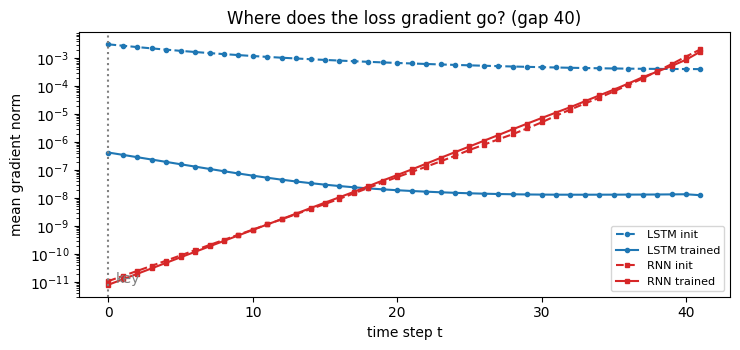

In [19]:
def state_gradients(kind, model, gap, n=256):
    '''Norm of dL/d(state_t) for every step t of a trained SeqClassifier, on n held-out
    sequences. state = C_t (LSTM) or h_t (RNN, GRU).'''
    x, y, _ = make_recall_batch(n, gap, torch.Generator().manual_seed(99))
    B, T, _ = x.shape
    Hm = model.head.in_features
    # The parameters are read back detached, so the initial states must carry requires_grad
    # for autograd to build a graph through the recurrence.
    h = torch.zeros(B, Hm, device=device, requires_grad=True); states = []
    if kind == 'LSTM':
        p = params_from_torch_lstm(model.rnn); C = torch.zeros(B, Hm, device=device, requires_grad=True)
        for t in range(T):
            h, C, _ = lstm_step(p, x[:, t], h, C); states.append(C)
    elif kind == 'RNN':
        r = model.rnn
        p = dict(W_xh=r.weight_ih_l0, W_hh=r.weight_hh_l0, b=r.bias_ih_l0 + r.bias_hh_l0)
        for t in range(T):
            h = rnn_step(p, x[:, t], h); states.append(h)
    else:                                                    # GRU, using the PyTorch-convention cell of section 7
        p = params_from_torch_gru(model.rnn)
        for t in range(T):
            h, _ = gru_step_torch(p, x[:, t], h); states.append(h)
    loss = F.cross_entropy(model.head(h), y)
    grads = torch.autograd.grad(loss, states)
    return [g.norm(dim=1).mean().item() for g in grads]

G_GAP = 40
set_seed(0); lstm_init = SeqClassifier('LSTM', keep_bias=KEEP_BIAS).to(device)    # the trained model's own initialization
set_seed(0); rnn_init = SeqClassifier('RNN').to(device)
GRAD = {'LSTM init': state_gradients('LSTM', lstm_init, G_GAP), 'LSTM trained': state_gradients('LSTM', LSTM_MODELS[G_GAP], G_GAP),
        'RNN init': state_gradients('RNN', rnn_init, G_GAP), 'RNN trained': state_gradients('RNN', RNN_MODELS[G_GAP], G_GAP)}
grad_lstm, grad_rnn = GRAD['LSTM trained'], GRAD['RNN trained']
print(f'gap {G_GAP}: mean norm of the loss gradient reaching the memory state (C_t for the LSTM, h_t for the RNN)')
print(f'{"step":>6s} ' + ''.join(f'{k:>14s}' for k in GRAD))
for t in (0, 1, 10, 20, 30, 40, 41):
    print(f'{t:6d} ' + ''.join(f'{GRAD[k][t]:14.2e}' for k in GRAD))
print(f'\nratio (gradient at the key step, t = 0) / (gradient at the query step, t = {G_GAP + 1}):')
print('   ' + '   '.join(f'{k} {GRAD[k][0] / GRAD[k][-1]:.1e}' for k in GRAD))

fig, a = plt.subplots(figsize=(7.5, 3.6))
for k, style in zip(GRAD, ['o--', 'o-', 's--', 's-']):
    a.semilogy(GRAD[k], style, ms=3, lw=1.5, color='tab:blue' if 'LSTM' in k else 'tab:red', label=k)
a.axvline(0, color='gray', ls=':'); a.text(0.5, a.get_ylim()[0] * 3, 'key', color='gray')
a.set_xlabel('time step t'); a.set_ylabel('mean gradient norm'); a.set_title(f'Where does the loss gradient go? (gap {G_GAP})'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()


At initialization the two architectures are already more than eight orders of magnitude apart (about nine, comparing the key/query ratios). The vanilla RNN's gradient is $2 \times 10^{-3}$ at the query and $10^{-11}$ at the key, a ratio of $5 \times 10^{-9}$, shrinking by a roughly constant factor per step, the straight line of the previous figure: no learning signal about the key ever arrives, so after 800 steps the trained RNN is exactly where it started, with the same ratio. The LSTM, its forget gates opened by the bias, starts with a gradient at the key that is *larger* than at the query (ratio 7.7). The highway alone cannot do that: a product of forget gates is at most $1$, and $\sigma(5)^{40} \approx 0.76$ here, so a ratio above $1$ is possible only because the indirect route through $h_t$, the one section 4.a measured as larger than the diagonal and section 4.b saw lifting the curve above $\sigma(b_f)^T$, adds to the highway's guaranteed floor. Training widens the ratio to 34 (the absolute values are small because the trained model's loss is near zero; the shape along $t$ is the point): the forget gates on the storing units are open across the whole gap, and the gradient settles to its smallest, flat value over the second half of the fillers, where nothing needs to change. That is the slide's answer made measurable: the forget gate reduces the gradient where it should, and nowhere else.

### 4.d What if the forget gate starts closed?

The same model, the same gap of 40, and only the initial forget-gate bias changed. A bias of $0$ is PyTorch's default: $f \approx 0.5$, so at initialization the highway loses half its signal per step and $0.5^{40} \approx 10^{-12}$ arrives at the key. We give each run 400 steps.


LSTM at gap 40, 400 steps each
 forget bias  initial f      f^40  final acc  steps to 95%


         0.0      0.500   9.1e-13      0.129         never


         1.0      0.731   3.6e-06      0.259         never


         2.0      0.881   6.2e-03      1.000           100


         3.0      0.953   1.4e-01      1.000            75


         5.0      0.993   7.6e-01      1.000            75
total 16.5 s


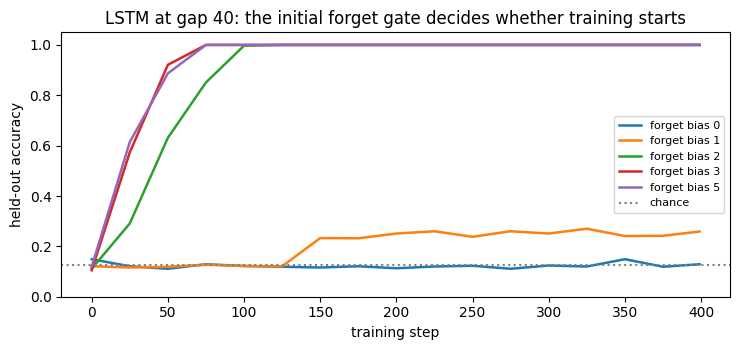

In [20]:
BIAS_SWEEP = [0.0, 1.0, 2.0, 3.0, 5.0]
SWEEP_HIST = {}
t_all = time.time()
print(f'LSTM at gap {G_GAP}, 400 steps each')
print(f'{"forget bias":>12s} {"initial f":>10s} {"f^40":>9s} {"final acc":>10s} {"steps to 95%":>13s}')
for b in BIAS_SWEEP:
    f0 = torch.sigmoid(torch.tensor(b)).item()
    _, hist = train_recall('LSTM', G_GAP, steps=400, keep_bias=b)
    SWEEP_HIST[b] = hist
    first = next((s for s, a in zip(hist['eval_steps'], hist['acc']) if a >= 0.95), None)
    print(f'{b:12.1f} {f0:10.3f} {f0 ** G_GAP:9.1e} {hist["acc"][-1]:10.3f} {(str(first) if first is not None else "never"):>13s}')
print(f'total {time.time() - t_all:.1f} s')

fig, a = plt.subplots(figsize=(7.5, 3.6))
for b in BIAS_SWEEP:
    h = SWEEP_HIST[b]
    a.plot(h['eval_steps'], h['acc'], lw=1.8, label=f'forget bias {b:g}')
a.axhline(1 / K_KEYS, color='gray', ls=':', label='chance')
a.set_xlabel('training step'); a.set_ylabel('held-out accuracy'); a.set_ylim(0, 1.05)
a.set_title(f'LSTM at gap {G_GAP}: the initial forget gate decides whether training starts'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()


The architecture alone is not enough: an LSTM whose forget gate starts at $0.5$ or $0.73$ behaves, at initialization, like the vanilla RNN of section 1 and stays at or near chance for the whole budget ($0.13$ and $0.26$ after 400 steps), while the same network with the gate at $0.88$ or more solves the gap within a hundred steps. This is why the forget gate is initialized positive in practice, and why the original LSTM of 1997 had no forget gate at all (section 6): with $f \equiv 1$ the carousel is always open.


## 5. Variants: peepholes and coupled gates

The slides mention two variants, both from the same family of small changes to the gate equations.

**Peephole connections** (Gers and Schmidhuber, *Recurrent nets that time and count*, IJCNN 2000) let the gates *see the cell state*: the forget and input gates receive $C_{t-1}$ alongside $[h_{t-1}, x_t]$, and the output gate receives the freshly updated $C_t$. Without peepholes the gates only see the cell indirectly, through $h_{t-1} = o_{t-1} * \tanh(C_{t-1})$, which is blank whenever the output gate was closed. With the figure's full connections each peephole adds an $H \times H$ matrix:

$$f_t = \sigma(W_f \cdot [C_{t-1}, h_{t-1}, x_t] + b_f), \quad i_t = \sigma(W_i \cdot [C_{t-1}, h_{t-1}, x_t] + b_i), \quad o_t = \sigma(W_o \cdot [C_t, h_{t-1}, x_t] + b_o).$$

**Coupled forget and input gates**: instead of separately deciding what to forget and what to add, make the decisions together, $i_t = 1 - f_t$:

$$C_t = f_t * C_{t-1} + (1 - f_t) * \tilde C_t .$$

The cell only writes where it forgets, and only forgets where it writes. This drops one weight block, and the count lands exactly on the GRU's, as section 8 shows. Both are a few lines of change to `lstm_step`.


In [21]:
def lstm_step_peephole(p, x, h, C):
    '''LSTM step with peephole connections: f and i also see C_{t-1}, o sees C_t.
    Extra parameters P_f, P_i, P_o of shape (H, H).'''
    z = torch.cat([h, x], dim=1)
    f = torch.sigmoid(z @ p['Wf'].T + C @ p['Pf'].T + p['bf'])
    i = torch.sigmoid(z @ p['Wi'].T + C @ p['Pi'].T + p['bi'])
    C_tilde = torch.tanh(z @ p['WC'].T + p['bC'])
    C_new = f * C + i * C_tilde
    o = torch.sigmoid(z @ p['Wo'].T + C_new @ p['Po'].T + p['bo'])     # peeks at the *new* cell
    return o * torch.tanh(C_new), C_new, dict(f=f, i=i, o=o)

def lstm_step_coupled(p, x, h, C):
    '''LSTM step with coupled gates: i_t = 1 - f_t. W_i and b_i are never used.'''
    z = torch.cat([h, x], dim=1)
    f = torch.sigmoid(z @ p['Wf'].T + p['bf'])
    C_tilde = torch.tanh(z @ p['WC'].T + p['bC'])
    C_new = f * C + (1 - f) * C_tilde                                    # forget here <=> write here
    o = torch.sigmoid(z @ p['Wo'].T + p['bo'])
    return o * torch.tanh(C_new), C_new, dict(f=f, i=1 - f, o=o)

# Run both variants on a random batch and count their parameters against the formulas.
set_seed(0)
p_var = init_lstm_params(D, H, seed=4)
g = torch.Generator().manual_seed(4)
for name in ('Pf', 'Pi', 'Po'):
    p_var[name] = (torch.randn(H, H, generator=g) / math.sqrt(H)).to(device)
x = torch.randn(5, D, device=device); h0 = torch.randn(5, H, device=device); C0 = torch.randn(5, H, device=device)
h_p, C_p, g_p = lstm_step_peephole(p_var, x, h0, C0)
h_c, C_c, g_c = lstm_step_coupled(p_var, x, h0, C0)
# Check the coupled cell against the verified standard cell of section 2: with W_i = -W_f and
# b_i = -b_f the standard input gate is sigmoid(-a) = 1 - sigmoid(a) = 1 - f, exactly the coupling.
p_tied = dict(p_var); p_tied['Wi'] = -p_var['Wf']; p_tied['bi'] = -p_var['bf']
h_ref, C_ref, g_ref = lstm_step(p_tied, x, h0, C0)
assert torch.allclose(g_c['i'], g_ref['i'], atol=1e-6), 'tied input gate is not 1 - f'
assert torch.allclose(h_c, h_ref, atol=1e-6) and torch.allclose(C_c, C_ref, atol=1e-6), 'coupled cell disagrees with the tied standard cell'
print(f'peephole step : h {tuple(h_p.shape)}, C {tuple(C_p.shape)}')
print(f'coupled  step : h {tuple(h_c.shape)}, C {tuple(C_c.shape)}')
print(f'coupled cell == lstm_step with W_i = -W_f, b_i = -b_f:  max |h diff| = {(h_c - h_ref).abs().max():.1e}, max |C diff| = {(C_c - C_ref).abs().max():.1e}')

def n_params(names, p):
    return sum(p[k].numel() for k in names)
base = ['Wf', 'Wi', 'WC', 'Wo', 'bf', 'bi', 'bC', 'bo']
counts = {'standard LSTM': n_params(base, p_var),
          'peephole LSTM': n_params(base + ['Pf', 'Pi', 'Po'], p_var),
          'coupled LSTM': n_params(['Wf', 'WC', 'Wo', 'bf', 'bC', 'bo'], p_var)}
formulas = {'standard LSTM': 4 * H * (H + D + 1),
            'peephole LSTM': 4 * H * (H + D + 1) + 3 * H * H,
            'coupled LSTM': 3 * H * (H + D + 1)}
print(f'\nparameter counts with D = {D}, H = {H}:')
for k in counts:
    assert counts[k] == formulas[k]
    print(f'  {k:14s} {counts[k]:5d}   formula {formulas[k]:5d}')
print('the coupled variant has 3 blocks, the same count as a GRU (section 8)')


peephole step : h (5, 8), C (5, 8)
coupled  step : h (5, 8), C (5, 8)
coupled cell == lstm_step with W_i = -W_f, b_i = -b_f:  max |h diff| = 6.0e-08, max |C diff| = 6.0e-08

parameter counts with D = 4, H = 8:
  standard LSTM    416   formula   416
  peephole LSTM    608   formula   608
  coupled LSTM     312   formula   312
the coupled variant has 3 blocks, the same count as a GRU (section 8)


## 6. A brief history, and where LSTMs stand

The LSTM as it is written in section 2 was assembled over eight years. The slides give the timeline:

| Year | Change | Reference |
|---|---|---|
| 1997 | The cell and the constant error carousel, input and output gates, **no forget gate**; trained with a mix of RTRL and truncated BPTT | Hochreiter and Schmidhuber, *Neural Computation 1997* |
| 1999 | The **forget gate**, so that the cell can reset itself in continual prediction | Gers, Schmidhuber and Cummins, *Learning to forget: continual prediction with LSTM*, ICANN 1999 |
| 2000 | **Peephole connections**, so the gates can time and count from the cell state | Gers and Schmidhuber, *Recurrent nets that time and count*, IJCNN 2000 |
| 2005 | The "vanilla LSTM" as used today, trained with full **BPTT**, in a bidirectional setting | Graves and Schmidhuber, *Framewise phoneme classification with bidirectional LSTM and other neural network architectures*, Neural Networks 2005 |

Section 4.d explains why the original design worked without a forget gate: with $f \equiv 1$ the highway is permanently open. The forget gate was added so that a network processing an unbounded stream could clear a cell once its content was stale, and section 4.d also shows the price: a forget gate that starts closed reintroduces the vanishing gradient the cell was invented to avoid.

Between **2013 and 2015** LSTMs became the state of the art on handwriting recognition, speech recognition, machine translation, parsing and image captioning, the last of which pairs a CNN encoder with an LSTM decoder that writes the sentence word by word. By 2020 other approaches, in particular **Transformers** built on self-attention, had become dominant for many of these tasks: the summary report of the WMT 2019 translation competition mentions "RNN" seven times and "Transformer" 105 times. The mechanisms of this lecture did not disappear with them. The additive path with a learned gate is the same idea as the residual connection of Week 5, and the gradient highway argument of section 4 is the argument for why both train.


## 7. The GRU

The **Gated Recurrent Unit** (Cho et al. 2014; evaluated against the LSTM by Chung et al., *Empirical Evaluation of Gated Recurrent Neural Networks on Sequence Modeling*, NeurIPS Workshop 2014) was proposed as a simpler alternative. Two changes, both from the slides:

- it **combines the forget and input gates into a single update gate** $z_t$,
- it **merges the cell state and the hidden state**, so there is no separate $C_t$ and no output gate.

With the deck's notation:

$$z_t = \sigma\left(W_z \cdot [h_{t-1}, x_t]\right) \qquad \text{update gate: how much of the state is replaced}$$
$$r_t = \sigma\left(W_r \cdot [h_{t-1}, x_t]\right) \qquad \text{reset gate: which parts of the old state feed the candidate}$$
$$\tilde h_t = \tanh\left(W \cdot [r_t * h_{t-1},\, x_t]\right)$$
$$h_t = (1 - z_t) * h_{t-1} + z_t * \tilde h_t$$

The deck writes the GRU without bias terms, while its LSTM equations have them; that is an artifact of the figure source, and we include biases in the code. The summary slide gives the two structural facts in one line: the LSTM's input and forget gates are coupled by the update gate (exactly the coupled variant of section 5, with $f_t = 1 - z_t$), and the reset gate is **applied directly to the previous hidden state** before it enters the candidate.

### 7.a From scratch, as the deck writes it


In [22]:
def init_gru_params(D, H, seed=0, update_bias=0.0):
    '''GRU parameters: W_z, W_r, W of shape (H, H + D) acting on [h_{t-1}, x_t], biases b_z, b_r,
    b_n, plus b_nh, a second candidate bias that PyTorch keeps inside the reset product.'''
    g = torch.Generator().manual_seed(seed)
    p = {name: (torch.randn(H, H + D, generator=g) / math.sqrt(H + D)).to(device) for name in ('Wz', 'Wr', 'W')}
    for name in ('bz', 'br', 'bn', 'bnh'):
        p[name] = torch.zeros(H, device=device)
    p['bz'] = p['bz'] + update_bias
    return p

def gru_step_deck(p, x, h, detach_h=False):
    '''One GRU step exactly as the deck writes it. The reset gate multiplies h_{t-1} BEFORE the
    candidate's matmul, and z_t is the weight on the NEW content. detach_h is used in 7.d.'''
    h_in = h.detach() if detach_h else h
    z_in = torch.cat([h_in, x], dim=1)
    z = torch.sigmoid(z_in @ p['Wz'].T + p['bz'])
    r = torch.sigmoid(z_in @ p['Wr'].T + p['br'])
    h_tilde = torch.tanh(torch.cat([r * h_in, x], dim=1) @ p['W'].T + p['bn'])
    h_new = (1 - z) * h + z * h_tilde                    # keep (1 - z) of the old state, write z of the new
    return h_new, dict(z=z, r=r, h_tilde=h_tilde)

H, D = 8, 4
p_gru = init_gru_params(D, H, seed=0)
h_prev = torch.randn(3, H, device=device); x = torch.randn(3, D, device=device)
h_new, g = gru_step_deck(p_gru, x, h_prev)
print(f'update gate z range [{g["z"].min():+.3f}, {g["z"].max():+.3f}]   reset gate r range [{g["r"].min():+.3f}, {g["r"].max():+.3f}]')

# The slide's question: reset gate all 1s and update gate all 0s, forced inside the real cell.
# Biases of +40 / -40 saturate the sigmoids to exactly 1 and 0 in float32, whatever [h, x] says.
p_frozen = dict(p_gru); p_frozen['br'] = p_gru['br'] + 40.0; p_frozen['bz'] = p_gru['bz'] - 40.0
h_frozen, g_frozen = gru_step_deck(p_frozen, x, h_prev)
print(f'\nforced gates: r min {g_frozen["r"].min():.6f}, z max {g_frozen["z"].max():.1e}')
assert torch.equal(h_frozen, h_prev), 'the GRU state changed despite r = 1, z = 0'
print('with r = 1, z = 0:  h_t = h_{t-1} exactly, whatever the input: the GRU\'s constant error carousel')
print('(r = 1 means the candidate sees the whole old state, but z = 0 means none of that candidate is written)')


update gate z range [+0.049, +0.940]   reset gate r range [+0.069, +0.790]

forced gates: r min 1.000000, z max 6.7e-17
with r = 1, z = 0:  h_t = h_{t-1} exactly, whatever the input: the GRU's constant error carousel
(r = 1 means the candidate sees the whole old state, but z = 0 means none of that candidate is written)


### 7.b Against `nn.GRUCell`: two conventions

Mapping the weights across as we did for the LSTM does **not** give a match, and the reasons are instructive. PyTorch's GRU (which follows the cuDNN formulation) is

$$r_t = \sigma(W_{ir} x_t + b_{ir} + W_{hr} h_{t-1} + b_{hr}), \quad z_t = \sigma(W_{iz} x_t + b_{iz} + W_{hz} h_{t-1} + b_{hz}),$$
$$n_t = \tanh\big(W_{in} x_t + b_{in} + r_t * (W_{hn} h_{t-1} + b_{hn})\big), \qquad h_t = (1 - z_t) * n_t + z_t * h_{t-1}.$$

Two differences. First, the **update gate has the opposite meaning**: in the deck $z_t$ weights the new content, in PyTorch it weights the old state, so $z = 0$ freezes the state in the deck and replaces it in PyTorch. Second, the **reset gate is applied after the recurrent matmul**, $r_t * (W_{hn} h_{t-1})$, rather than before, $W \cdot [r_t * h_{t-1}, \cdot]$. The first is a relabeling ($z \leftrightarrow 1 - z$); the second is a genuinely different function, cheaper because $r_t$ multiplies a vector instead of gating the input to a matrix product. Both are checked below, and then a second from-scratch cell in PyTorch's convention is verified exactly against `nn.GRUCell` and `nn.GRU`.


In [23]:
def load_into_torch_gru(p, module):
    '''Copy deck-style GRU parameters into an nn.GRUCell / nn.GRU. PyTorch block order: r, z, n.'''
    H = p['bz'].numel()
    order = ['Wr', 'Wz', 'W']
    with torch.no_grad():
        _w(module, 'weight_hh').copy_(torch.cat([p[k][:, :H] for k in order]))
        _w(module, 'weight_ih').copy_(torch.cat([p[k][:, H:] for k in order]))
        if _w(module, 'bias_ih') is not None:
            _w(module, 'bias_ih').copy_(torch.cat([p['br'], p['bz'], p['bn']]))
            _w(module, 'bias_hh').copy_(torch.cat([torch.zeros_like(p['br']), torch.zeros_like(p['bz']), p['bnh']]))

# 1. The deck's GRU does not match nn.GRUCell after the weight map.
p_g = init_gru_params(D, H, seed=1)
ref_gru = nn.GRUCell(D, H).to(device)
load_into_torch_gru(p_g, ref_gru)
x = torch.randn(3, D, device=device); h0 = torch.randn(3, H, device=device)
ours, parts = gru_step_deck(p_g, x, h0)
theirs = ref_gru(x, h0)
print(f'deck GRU vs nn.GRUCell:                     max |diff| = {(ours - theirs).abs().max():.4f}   -> they disagree')
swapped = parts['z'] * h0 + (1 - parts['z']) * parts['h_tilde']        # reason 1 undone: z weights the old state
print(f'after swapping z for (1 - z) only:          max |diff| = {(swapped - theirs).abs().max():.4f}   -> reason 2 (reset placement) remains')

# 2. A from-scratch cell in PyTorch's convention matches exactly.
def gru_step_torch(p, x, h):
    '''One GRU step in PyTorch's convention: reset applied after the matmul, z weights the old state.'''
    H = p['bz'].numel()
    z_in = torch.cat([h, x], dim=1)
    r = torch.sigmoid(z_in @ p['Wr'].T + p['br'])
    z = torch.sigmoid(z_in @ p['Wz'].T + p['bz'])
    n = torch.tanh(x @ p['W'][:, H:].T + p['bn'] + r * (h @ p['W'][:, :H].T + p['bnh']))
    return (1 - z) * n + z * h, dict(z=z, r=r, n=n)

def params_from_torch_gru(module):
    '''Deck-layout parameters (PyTorch convention) from an nn.GRUCell or nn.GRU (layer 0).'''
    W_ih, W_hh = _w(module, 'weight_ih').detach(), _w(module, 'weight_hh').detach()
    b_ih, b_hh = _w(module, 'bias_ih').detach(), _w(module, 'bias_hh').detach()
    r_h, z_h, n_h = W_hh.chunk(3); r_x, z_x, n_x = W_ih.chunk(3)
    b_ir, b_iz, b_in = b_ih.chunk(3); b_hr, b_hz, b_hn = b_hh.chunk(3)
    return dict(Wr=torch.cat([r_h, r_x], 1), Wz=torch.cat([z_h, z_x], 1), W=torch.cat([n_h, n_x], 1),
                br=b_ir + b_hr, bz=b_iz + b_hz, bn=b_in, bnh=b_hn)

ours_t, _ = gru_step_torch(p_g, x, h0)
assert torch.allclose(ours_t, theirs, atol=1e-6), 'PyTorch-convention GRU disagrees with nn.GRUCell'
print(f'\nPyTorch-convention GRU vs nn.GRUCell:       max |diff| = {(ours_t - theirs).abs().max():.1e}   -> exact')

# whole sequence against nn.GRU with random (default-initialized) weights, read back with params_from_torch_gru
ref_seq = nn.GRU(D, H, batch_first=True).to(device)
p_back = params_from_torch_gru(ref_seq)
X = torch.randn(3, 15, D, device=device)
h = torch.zeros(3, H, device=device); hs = []
for t in range(X.shape[1]):
    h, _ = gru_step_torch(p_back, X[:, t], h); hs.append(h)
out_ref, _ = ref_seq(X)
assert torch.allclose(torch.stack(hs, 1), out_ref, atol=1e-6)
print(f'15 steps vs nn.GRU:                         max |diff| = {(torch.stack(hs, 1) - out_ref).abs().max():.1e}   -> exact')


deck GRU vs nn.GRUCell:                     max |diff| = 1.1268   -> they disagree
after swapping z for (1 - z) only:          max |diff| = 0.2301   -> reason 2 (reset placement) remains

PyTorch-convention GRU vs nn.GRUCell:       max |diff| = 2.4e-07   -> exact
15 steps vs nn.GRU:                         max |diff| = 7.5e-08   -> exact


### 7.c The GRU versus the gap

Same experiment, `nn.GRU`. The keep-gate is the update gate: in PyTorch's convention $z_t$ multiplies $h_{t-1}$, so a bias of $+5$ on the $z$ block starts the unit at $z \approx 0.993$, keeping almost all of its state (in the deck's convention this is $1 - z_t \approx 0.993$).


In [24]:
GRU_MODELS = run_all_gaps('GRU', keep_bias=KEEP_BIAS)


GRU: 800 Adam steps per gap, learning rate 1e-3, batch 128, hidden 64, keep-gate bias 5
  gap  final acc  steps to 95%  seconds


    5      1.000           275      1.0


   10      1.000           275      1.6


   20      1.000           275      2.7


   40      1.000           400      5.2


   80      1.000           375      9.7
total 20.3 s


The GRU solves every gap too, but reaches 95% only after 275 to 400 steps where the LSTM needed 50 to 75. Both cells start with their keep-gate at $0.993$; the difference is in what else that gate does. In the GRU the update gate is *also* the input gate ($1 - z_t$ keeps, $z_t$ writes, in the deck's convention), so a unit that keeps 99% of its state can write only 1% of the candidate at the key step, and the network has to move the gate away from its initialization before it can store anything. The LSTM's separate input gate starts at $0.5$ and can write immediately. Section 8 puts the curves side by side.


### 7.d The slide's homework, answered: how does a GRU address vanishing gradients?

The lecture's homework question is "how does GRU address vanishing gradients?", and the next lecture's review answers it in one line: *the same reason as the LSTM; there is a gradient highway, affected only by the update gate, which controls gradients by design and necessity.* In the deck's convention, $h_t = (1 - z_t) * h_{t-1} + z_t * \tilde h_t$, so the direct route from $h_{t-1}$ to $h_t$ is multiplication by $(1 - z_t)$ and

$$\frac{\partial h_T}{\partial h_0}\Big|_{\text{highway}} = \mathrm{diag}\Big(\prod_{t=1}^{T} (1 - z_t)\Big),$$

with no weight matrix and no $\tanh'$ on the path. Unlike the LSTM, the GRU has no separate cell, so the same $h_{t-1}$ also enters both gates and the candidate; those indirect routes add to the Jacobian. As in section 4 we check the highway alone with a detached $h$, then look at the full Jacobian, and finally measure the gradient flow in the trained gap-40 GRU.


GRU highway only: dh_T/dh_0 == diag(prod_t (1 - z_t))    max |diff| = 1.1e-08
full GRU: diagonal vs prod_t (1 - z_t)   max |diff| = 4.0e-02;   diagonal norm 0.177, off-diagonal norm 0.248

gap-40 models, gradient at the key step / gradient at the query step:
  at initialization: LSTM 7.7e+00   GRU 7.6e-01   RNN 5.2e-09
  after training   : LSTM 3.4e+01   GRU 4.4e+01   RNN 4.6e-09


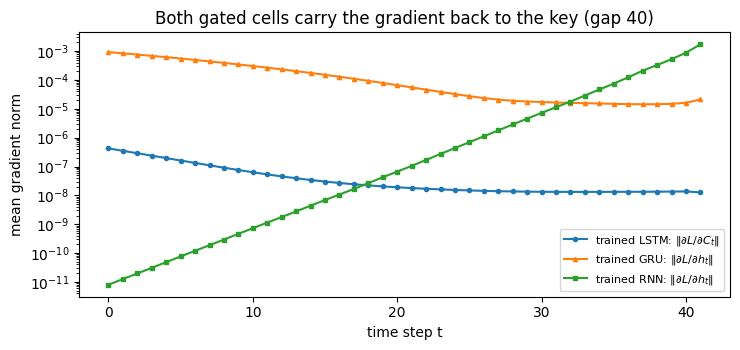

In [25]:
set_seed(0)
p_ghw = init_gru_params(D_S, H_S, seed=5, update_bias=-1.0)      # deck convention: negative bias keeps more
X_g = torch.randn(1, T_S, D_S, device=device)
h0g = torch.randn(1, H_S, device=device, requires_grad=True)

def gru_deck_forward(p, X, h0, detach_h=False):
    hs, zs, h = [], [], h0
    for t in range(X.shape[1]):
        h, g = gru_step_deck(p, X[:, t], h, detach_h); hs.append(h); zs.append(g['z'])
    return torch.stack(hs, 1), torch.stack(zs, 1)

h_seq, z_seq = gru_deck_forward(p_ghw, X_g, h0g, detach_h=True)
J_hw = jacobian_wrt(h_seq[:, -1], h0g)
keep_prod = (1 - z_seq[0]).prod(dim=0)
assert torch.allclose(J_hw, torch.diag(keep_prod), atol=1e-6), 'GRU highway is not the product of (1 - z_t)'
print(f'GRU highway only: dh_T/dh_0 == diag(prod_t (1 - z_t))    max |diff| = {(J_hw - torch.diag(keep_prod)).abs().max():.1e}')

h_full, z_full = gru_deck_forward(p_ghw, X_g, h0g)
J_gfull = jacobian_wrt(h_full[:, -1], h0g)
print(f'full GRU: diagonal vs prod_t (1 - z_t)   max |diff| = {(torch.diag(J_gfull) - (1 - z_full[0]).prod(0)).abs().max():.1e};   '
      f'diagonal norm {torch.diag(J_gfull).norm():.3f}, off-diagonal norm {(J_gfull - torch.diag(torch.diag(J_gfull))).norm():.3f}')

# The trained models: gradient reaching each step, GRU added to the section 4.c picture.
set_seed(0); gru_init = SeqClassifier('GRU', keep_bias=KEEP_BIAS).to(device)
grad_gru = state_gradients('GRU', GRU_MODELS[G_GAP], G_GAP)
grad_gru_init = state_gradients('GRU', gru_init, G_GAP)
print(f'\ngap-{G_GAP} models, gradient at the key step / gradient at the query step:')
print(f'  at initialization: LSTM {GRAD["LSTM init"][0] / GRAD["LSTM init"][-1]:.1e}   GRU {grad_gru_init[0] / grad_gru_init[-1]:.1e}   RNN {GRAD["RNN init"][0] / GRAD["RNN init"][-1]:.1e}')
print(f'  after training   : LSTM {grad_lstm[0] / grad_lstm[-1]:.1e}   GRU {grad_gru[0] / grad_gru[-1]:.1e}   RNN {grad_rnn[0] / grad_rnn[-1]:.1e}')

fig, a = plt.subplots(figsize=(7.5, 3.6))
a.semilogy(grad_lstm, 'o-', ms=3, lw=1.5, label='trained LSTM: $\\|\\partial L/\\partial C_t\\|$')
a.semilogy(grad_gru, '^-', ms=3, lw=1.5, label='trained GRU: $\\|\\partial L/\\partial h_t\\|$')
a.semilogy(grad_rnn, 's-', ms=3, lw=1.5, label='trained RNN: $\\|\\partial L/\\partial h_t\\|$')
a.set_xlabel('time step t'); a.set_ylabel('mean gradient norm'); a.set_title(f'Both gated cells carry the gradient back to the key (gap {G_GAP})'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()


The GRU's highway is confirmed to the same precision as the LSTM's, and with the same caveat: the full Jacobian has off-diagonal terms of the same order as its diagonal ($0.25$ against $0.18$ here), because $h_{t-1}$ feeds the gates and the candidate as well as the highway. In the trained gap-40 models the picture matches section 4.c: the gradient at the key is 44 times the gradient at the query for the GRU, 34 times for the LSTM, and $5 \times 10^{-9}$ for the RNN. At initialization the GRU's ratio is $0.76$ against the LSTM's $7.7$, a reflection of the same coupling that slowed its training, and still eight orders of magnitude better than the vanilla RNN. So the homework answer holds as measured: the GRU addresses vanishing gradients by the same mechanism as the LSTM, a highway whose only multiplier is a gate.


## 8. GRUs vs LSTMs: accuracy, speed and parameters

The summary slide lists the differences and ends with advice:

| | LSTM | GRU |
|---|---|---|
| gates | three: forget, input, output | two: update, reset |
| memory | internal cell $C_t$ separate from the exposed $h_t$ | none; $h_t$ is the memory |
| output gate | yes | no |
| erase / write | decided separately by $f_t$ and $i_t$ | coupled through $z_t$ |
| blocks of weights | 4 | 3 |

> "LSTM a good default choice (especially if data has long-range dependencies, or if training data is large); switch to GRUs for speed and fewer parameters."

### 8.a Accuracy versus gap, all three cells

The table from sections 1, 2 and 7 in one figure, with the measured seconds per run alongside.


  gap    RNN acc  LSTM acc   GRU acc      RNN sec  LSTM sec   GRU sec
    5      1.000     1.000     1.000          1.0       1.4       1.0
   10      1.000     1.000     1.000          0.7       2.1       1.6
   20      1.000     1.000     1.000          1.2       3.6       2.7
   40      0.114     1.000     1.000          2.2       6.3       5.2
   80      0.125     1.000     1.000          3.9      13.2       9.7

total training seconds: RNN 9.1, LSTM 26.7, GRU 20.3   ->  LSTM / GRU time ratio 1.31


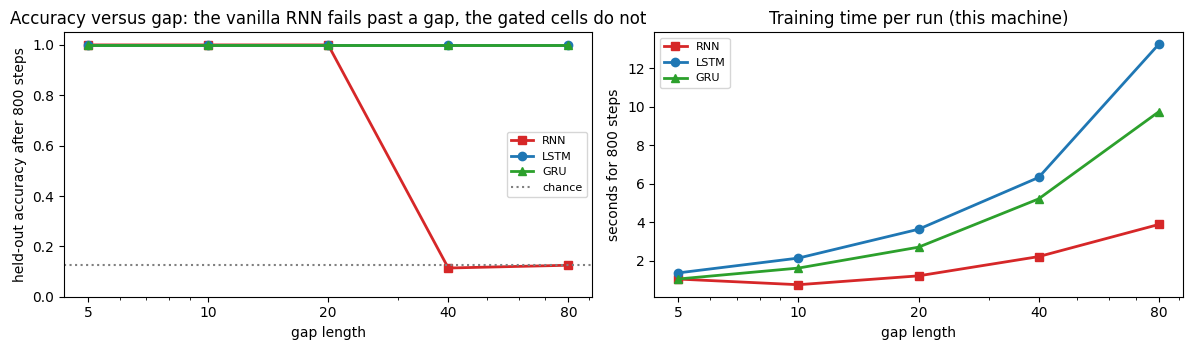

In [26]:
KINDS = ['RNN', 'LSTM', 'GRU']
STYLE = {'RNN': ('s-', 'tab:red'), 'LSTM': ('o-', 'tab:blue'), 'GRU': ('^-', 'tab:green')}
print(f'{"gap":>5s} ' + ''.join(f'{k + " acc":>10s}' for k in KINDS) + '   ' + ''.join(f'{k + " sec":>10s}' for k in KINDS))
for gap in GAPS:
    print(f'{gap:5d} ' + ''.join(f'{HIST[(k, gap)]["acc"][-1]:10.3f}' for k in KINDS)
          + '   ' + ''.join(f'{HIST[(k, gap)]["seconds"]:10.1f}' for k in KINDS))
sec = {k: sum(HIST[(k, g)]['seconds'] for g in GAPS) for k in KINDS}
print(f'\ntotal training seconds: ' + ', '.join(f'{k} {sec[k]:.1f}' for k in KINDS)
      + f'   ->  LSTM / GRU time ratio {sec["LSTM"] / sec["GRU"]:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for k in KINDS:
    m, c = STYLE[k]
    ax[0].plot(GAPS, [HIST[(k, g)]['acc'][-1] for g in GAPS], m, color=c, lw=2, ms=6, label=k)
    ax[1].plot(GAPS, [HIST[(k, g)]['seconds'] for g in GAPS], m, color=c, lw=2, ms=6, label=k)
ax[0].axhline(1 / K_KEYS, color='gray', ls=':', label='chance')
ax[0].set_xscale('log'); ax[0].set_xticks(GAPS); ax[0].set_xticklabels(GAPS)
ax[0].set_xlabel('gap length'); ax[0].set_ylabel('held-out accuracy after 800 steps'); ax[0].set_ylim(0, 1.05)
ax[0].set_title('Accuracy versus gap: the vanilla RNN fails past a gap, the gated cells do not'); ax[0].legend(fontsize=8)
ax[1].set_xscale('log'); ax[1].set_xticks(GAPS); ax[1].set_xticklabels(GAPS)
ax[1].set_xlabel('gap length'); ax[1].set_ylabel('seconds for 800 steps'); ax[1].set_title('Training time per run (this machine)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


The right panel is the slide's speed claim measured. With the same hidden size the GRU has three quarters of the LSTM's parameters and, on this machine, trained faster at every gap; the ratio of total seconds is printed above. The absolute seconds depend on the machine and on how busy it is, the ordering RNN, GRU, LSTM does not.


### Widget 4: gap length

Drag `gap` through the five values. The left panel shows the three accuracy curves at that gap; the right panel marks where you are on the accuracy-versus-gap plot. At short gaps all three curves rise; past the RNN's limit only the gated curves do. The LSTM's curve rises first at every gap, the GRU's needs a few hundred steps, and neither slows down much as the gap grows.


In [27]:
def gap_demo(gap_index=3):
    gap = GAPS[gap_index]
    fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
    for k in KINDS:
        m, c = STYLE[k]
        h = HIST[(k, gap)]
        ax[0].plot(h['eval_steps'], h['acc'], color=c, lw=2, label=f'{k}: final {h["acc"][-1]:.2f}')
        ax[1].plot(GAPS, [HIST[(k, g)]['acc'][-1] for g in GAPS], m, color=c, lw=1.5, ms=5, alpha=0.6, label=k)
    ax[0].axhline(1 / K_KEYS, color='gray', ls=':')
    ax[0].set_xlabel('training step'); ax[0].set_ylabel('held-out accuracy'); ax[0].set_ylim(0, 1.05)
    ax[0].set_title(f'gap {gap}: accuracy during training'); ax[0].legend(fontsize=8)
    ax[1].axvline(gap, color='k', ls='--'); ax[1].set_xscale('log'); ax[1].set_xticks(GAPS); ax[1].set_xticklabels(GAPS)
    ax[1].set_xlabel('gap length'); ax[1].set_ylabel('final accuracy'); ax[1].set_ylim(0, 1.05); ax[1].set_title('where you are'); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

interact(gap_demo, gap_index=IntSlider(min=0, max=len(GAPS) - 1, step=1, value=3, description='gap index'));


interactive(children=(IntSlider(value=3, description='gap index', max=4), Output()), _dom_classes=('widget-int…

### 8.b Parameter counts: "lesser parameters to learn"

With input size $d$ and hidden size $h$, the concatenation $[h_{t-1}, x_t]$ has length $h + d$, so each weight block is $h \times (h + d)$ with a bias of $h$ entries, that is $dh + h^2 + h$ parameters per block. Counting the blocks:

| Cell | Blocks | Parameters |
|---|---|---|
| vanilla RNN | 1 | $dh + h^2 + h$ |
| **GRU** | 3 ($z, r, \tilde h$) | $3(dh + h^2 + h)$ |
| **LSTM** | 4 ($f, i, \tilde C, o$) | $4(dh + h^2 + h)$ |

So a GRU costs **three quarters** of an LSTM at the same width, which is the quantitative content of the slide's "lesser parameters to learn". PyTorch's modules carry one extra bias vector per block (`bias_ih` and `bias_hh`), which we account for exactly.


d = 10, h = 20
cell     deck formula    PyTorch   difference
RNN               620        640           20   (= 1 extra bias vectors of size 20)
GRU              1860       1920           60   (= 3 extra bias vectors of size 20)
LSTM             2480       2560           80   (= 4 extra bias vectors of size 20)

GRU : LSTM parameter ratio = 0.75  (exactly 3/4)
the recall-task models (d = 13, h = 64): RNN 5,056, LSTM 20,224, GRU 15,168


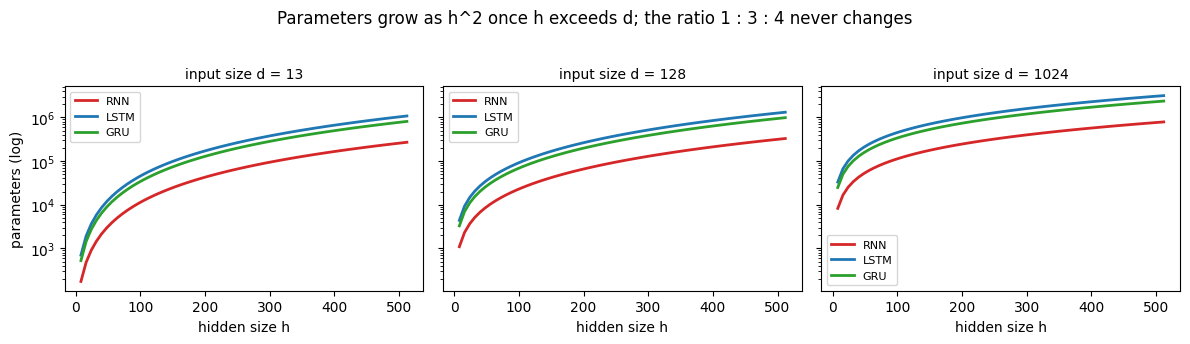

In [28]:
def formula(kind, d, h):
    '''Deck formula for the parameter count: blocks * (d h + h^2 + h).'''
    blocks = {'RNN': 1, 'GRU': 3, 'LSTM': 4}[kind]
    return blocks * (d * h + h * h + h)

D_, H_ = 10, 20
print(f'd = {D_}, h = {H_}')
print(f'{"cell":6s} {"deck formula":>14s} {"PyTorch":>10s} {"difference":>12s}')
for kind, mod in [('RNN', nn.RNNCell(D_, H_)), ('GRU', nn.GRUCell(D_, H_)), ('LSTM', nn.LSTMCell(D_, H_))]:
    blocks = {'RNN': 1, 'GRU': 3, 'LSTM': 4}[kind]
    actual = count_params(mod)
    assert actual - formula(kind, D_, H_) == blocks * H_          # PyTorch's second bias vector per block
    print(f'{kind:6s} {formula(kind, D_, H_):14d} {actual:10d} {actual - formula(kind, D_, H_):12d}   (= {blocks} extra bias vectors of size {H_})')

ratio = formula('GRU', D_, H_) / formula('LSTM', D_, H_)
assert abs(ratio - 0.75) < 1e-9
print(f'\nGRU : LSTM parameter ratio = {ratio:.2f}  (exactly 3/4)')
print(f'the recall-task models (d = {D_IN}, h = 64): ' + ', '.join(f'{k} {count_params(m[GAPS[0]].rnn):,}' for k, m in [('RNN', RNN_MODELS), ('LSTM', LSTM_MODELS), ('GRU', GRU_MODELS)]))

# Static sweep: parameters versus hidden size for three input sizes.
hs = np.arange(8, 513, 8)
fig, ax = plt.subplots(1, 3, figsize=(12, 3.3), sharey=True)
for a, d in zip(ax, [13, 128, 1024]):
    for kind in KINDS:
        a.plot(hs, [formula(kind, d, h) for h in hs], color=STYLE[kind][1], lw=2, label=kind)
    a.set_yscale('log'); a.set_xlabel('hidden size h'); a.set_title(f'input size d = {d}', fontsize=10); a.legend(fontsize=8)
ax[0].set_ylabel('parameters (log)')
fig.suptitle('Parameters grow as h^2 once h exceeds d; the ratio 1 : 3 : 4 never changes', y=1.03)
plt.tight_layout(); plt.show()


### Widget 5: hidden size versus parameters

Drag `hidden` and `input_size`. The bars keep the ratio $1 : 3 : 4$ at every setting, and the numbers under them are the deck formula. Set `input_size` large compared with `hidden` and the $dh$ term dominates; set `hidden` large and the $h^2$ term does.


In [29]:
def params_demo(hidden=64, input_size=13):
    counts = [formula(k, input_size, hidden) for k in KINDS]
    fig, a = plt.subplots(figsize=(7, 3.4))
    bars = a.bar(KINDS, counts, color=[STYLE[k][1] for k in KINDS])
    for b, v in zip(bars, counts):
        a.text(b.get_x() + b.get_width() / 2, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
    a.margins(y=0.2); a.set_ylabel('parameters')
    a.set_title(f'd = {input_size}, h = {hidden}:  d h + h^2 + h = {input_size * hidden + hidden * hidden + hidden:,} per block;  GRU / LSTM = {counts[2] / counts[1]:.2f}')
    plt.tight_layout(); plt.show()

interact(params_demo,
         hidden=IntSlider(min=8, max=512, step=8, value=64),
         input_size=IntSlider(min=1, max=1024, step=1, value=13));


interactive(children=(IntSlider(value=64, description='hidden', max=512, min=8, step=8), IntSlider(value=13, d…

## 9. Explore and verify

Every from-scratch component in this notebook has been checked against a PyTorch reference along the way. The cell below reruns the checks in one place, on the trained gap-80 models and at three sizes, so that a change anywhere above is caught here.


In [30]:
def verify_all():
    checks = []
    # (1) our LSTM reproduces the trained nn.LSTM on new sequences, at the longest gap
    x, _, _ = make_recall_batch(16, 80, torch.Generator().manual_seed(2024))
    with torch.no_grad():
        h_ours, _, _ = lstm_forward(params_from_torch_lstm(LSTM_MODELS[80].rnn), x)
        h_ref, _ = LSTM_MODELS[80].rnn(x)
    checks.append(('LSTM from scratch == trained nn.LSTM, 82 steps (float32)', (h_ours - h_ref).abs().max().item(), 1e-3))
    # (2) our PyTorch-convention GRU reproduces the trained nn.GRU
    with torch.no_grad():
        p = params_from_torch_gru(GRU_MODELS[80].rnn)
        h = torch.zeros(16, 64, device=device); hs = []
        for t in range(x.shape[1]):
            h, _ = gru_step_torch(p, x[:, t], h); hs.append(h)
        g_ref, _ = GRU_MODELS[80].rnn(x)
    checks.append(('GRU from scratch == trained nn.GRU, 82 steps (float32)', (torch.stack(hs, 1) - g_ref).abs().max().item(), 1e-3))
    # (3) the two highways
    _, C_seq, gates = lstm_forward(p_hw, X_hw, h0_hw, C0_hw, detach_h=True)
    checks.append(('LSTM highway dC_T/dC_0 == diag(prod f_t)', (jacobian_wrt(C_seq[:, -1], C0_hw) - torch.diag(gates['f'][0].prod(0))).abs().max().item(), 1e-6))
    h_seq, z_seq = gru_deck_forward(p_ghw, X_g, h0g, detach_h=True)
    checks.append(('GRU highway dh_T/dh_0 == diag(prod (1 - z_t))', (jacobian_wrt(h_seq[:, -1], h0g) - torch.diag((1 - z_seq[0]).prod(0))).abs().max().item(), 1e-6))
    # (4) parameter formulas at three sizes
    worst = 0
    for d, hh in [(4, 8), (13, 64), (100, 256)]:
        for kind, mod in [('RNN', nn.RNNCell(d, hh)), ('GRU', nn.GRUCell(d, hh)), ('LSTM', nn.LSTMCell(d, hh))]:
            blocks = {'RNN': 1, 'GRU': 3, 'LSTM': 4}[kind]
            worst = max(worst, abs(count_params(mod) - blocks * hh - formula(kind, d, hh)))
    checks.append(('parameter formulas at (d, h) = (4, 8), (13, 64), (100, 256)', worst, 0.5))
    for name, err, tol in checks:
        assert err <= tol, f'{name}: {err}'
        print(f'  ok  {name:60s} max |diff| = {err:.1e}')
    print('all checks pass')

verify_all()


  ok  LSTM from scratch == trained nn.LSTM, 82 steps (float32)     max |diff| = 3.6e-06
  ok  GRU from scratch == trained nn.GRU, 82 steps (float32)       max |diff| = 9.9e-05
  ok  LSTM highway dC_T/dC_0 == diag(prod f_t)                     max |diff| = 7.5e-09
  ok  GRU highway dh_T/dh_0 == diag(prod (1 - z_t))                max |diff| = 1.1e-08
  ok  parameter formulas at (d, h) = (4, 8), (13, 64), (100, 256)  max |diff| = 0.0e+00
all checks pass


The forget gate alone decides how long a cell remembers. With nothing written ($i_t = 0$) and a constant gate value $f$, the cell decays as $f^t$, so its half-life is $\ln 2 / \ln(1/f)$ steps: about one step at $f = 0.5$, seven at $f = 0.9$, sixty-nine at $f = 0.99$. The sweep below draws that decay for five gate values.


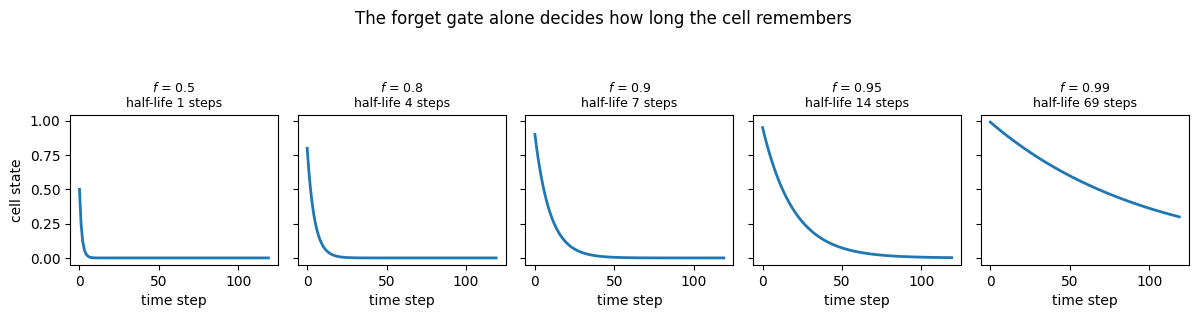

In [31]:
# Static sweep: the forget gate sets the half-life of the cell state.
fig, ax = plt.subplots(1, 5, figsize=(12, 2.9), sharey=True)
for a, f_val in zip(ax, [0.5, 0.8, 0.9, 0.95, 0.99]):
    trace = [f_val ** t for t in range(1, 121)]
    half = next((t + 1 for t, v in enumerate(trace) if v <= 0.5), None)
    a.plot(trace, lw=2)
    a.set_title(f'$f$ = {f_val}\nhalf-life {half} steps', fontsize=9)
    a.set_xlabel('time step')
ax[0].set_ylabel('cell state')
fig.suptitle('The forget gate alone decides how long the cell remembers', y=1.08)
plt.tight_layout(); plt.show()


Now the same thing under your control. Drag the slider and watch what changes.

### Widget 6: the cell path against a plain RNN at the same depth

`forget` is the (constant) forget gate on the LSTM cell path; `rnn_scale` is the size of the plain RNN's recurrent weights. The LSTM trace is a clean exponential $f^t$ whose rate you choose; the RNN trace is whatever the repeated matrix and $\tanh$ produce, and at no scale does it hold the signal.


In [32]:
def compare(forget=0.95, rnn_scale=0.9, steps=60):
    set_seed(0)
    Wl = torch.randn(H_DEMO, H_DEMO, device=device) * rnn_scale
    hv = torch.ones(H_DEMO, device=device)
    lstm_trace, rnn_trace = [], []
    C = 1.0
    for _ in range(steps):
        C *= forget
        lstm_trace.append(C)
        hv = torch.tanh(Wl @ hv)
        rnn_trace.append(F.cosine_similarity(hv, torch.ones(H_DEMO, device=device), dim=0).abs().item() * hv.norm().item() / math.sqrt(H_DEMO))
    fig, a = plt.subplots(figsize=(7.5, 3.4))
    a.semilogy(lstm_trace, lw=2, label=f'LSTM cell path, f = {forget:.3f}')
    a.semilogy(np.maximum(rnn_trace, 1e-12), lw=2, label=f'plain RNN, |W| scale {rnn_scale:.1f} (signal component)')
    a.set_ylim(1e-12, 2); a.set_xlabel('time step'); a.set_ylabel('signal retained'); a.legend(fontsize=8)
    plt.tight_layout(); plt.show()

interact(compare, forget=FloatSlider(min=0.5, max=0.999, step=0.001, value=0.95, readout_format='.3f'),
                  rnn_scale=FloatSlider(min=0.3, max=1.5, step=0.1, value=0.9),
                  steps=IntSlider(min=20, max=120, step=20, value=60));


interactive(children=(FloatSlider(value=0.95, description='forget', max=0.999, min=0.5, readout_format='.3f', …

Finally, the training curves themselves. The static figure overlays the three cells at gap 40, loss and accuracy side by side; the chooser below lets you pick the gap and switch cells on and off.


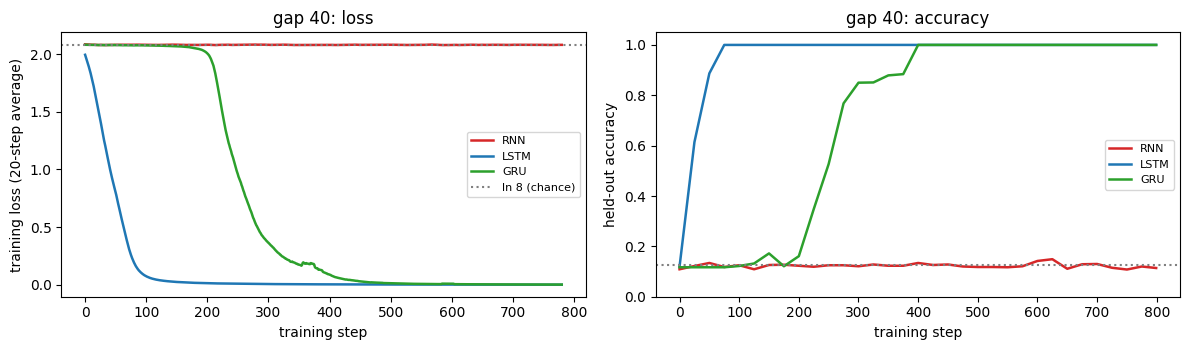

In [33]:
def smooth(v, k=20):
    return np.convolve(v, np.ones(k) / k, mode='valid')

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for k in KINDS:
    h = HIST[(k, 40)]
    ax[0].plot(smooth(h['loss']), color=STYLE[k][1], lw=1.8, label=k)
    ax[1].plot(h['eval_steps'], h['acc'], color=STYLE[k][1], lw=1.8, label=k)
ax[0].axhline(math.log(K_KEYS), color='gray', ls=':', label='ln 8 (chance)')
ax[0].set_xlabel('training step'); ax[0].set_ylabel('training loss (20-step average)'); ax[0].set_title('gap 40: loss'); ax[0].legend(fontsize=8)
ax[1].axhline(1 / K_KEYS, color='gray', ls=':'); ax[1].set_ylim(0, 1.05)
ax[1].set_xlabel('training step'); ax[1].set_ylabel('held-out accuracy'); ax[1].set_title('gap 40: accuracy'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


### Widget 7: overlay the training curves

Choose a `gap`, tick the cells you want to see, and pick `metric`. Two things to look for: at every gap the LSTM's loss starts falling well before the GRU's (50 to 75 steps to 95% accuracy against 275 to 400, for the reason given in section 7.c), and at gaps 40 and 80 the RNN's loss never leaves $\ln 8$.


In [34]:
def curves_demo(gap=40, RNN=True, LSTM=True, GRU=True, metric='accuracy'):
    fig, a = plt.subplots(figsize=(7.5, 3.6))
    for k, on in zip(KINDS, (RNN, LSTM, GRU)):
        if not on:
            continue
        h = HIST[(k, gap)]
        if metric == 'accuracy':
            a.plot(h['eval_steps'], h['acc'], color=STYLE[k][1], lw=2, label=f'{k}: final {h["acc"][-1]:.2f}')
        else:
            a.plot(smooth(h['loss']), color=STYLE[k][1], lw=2, label=f'{k}: final {np.mean(h["loss"][-20:]):.3f}')
    if metric == 'accuracy':
        a.axhline(1 / K_KEYS, color='gray', ls=':'); a.set_ylim(0, 1.05); a.set_ylabel('held-out accuracy')
    else:
        a.axhline(math.log(K_KEYS), color='gray', ls=':'); a.set_ylabel('training loss (20-step average)')
    a.set_xlabel('training step'); a.set_title(f'gap {gap}'); a.legend(fontsize=8)
    plt.tight_layout(); plt.show()

interact(curves_demo, gap=Dropdown(options=GAPS, value=40),
         RNN=Checkbox(value=True), LSTM=Checkbox(value=True), GRU=Checkbox(value=True),
         metric=Dropdown(options=['accuracy', 'loss'], value='accuracy'));


interactive(children=(Dropdown(description='gap', index=3, options=(5, 10, 20, 40, 80), value=40), Checkbox(va…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **Long-term dependencies** | A plain RNN rewrites its whole state every step; on the recall task it learns short gaps and sits at chance past a gap, because the gradient that would teach it never arrives at the key |
| **Two states** | An LSTM carries a hidden state $h_t$ **and** a cell state $C_t$; the cell stores long-term information and the LSTM can erase, write and read it |
| **Three gates** | Forget (what to keep), input (what to write), output (what to read); sigmoid layers times a pointwise product, every element in $[0, 1]$, computed from the current context |
| **Cell update** | $C_t = f_t * C_{t-1} + i_t * \tilde C_t$: erase some, write some; then $h_t = o_t * \tanh(C_t)$ |
| **Constant error carousel** | $f = 1, i = 0 \Rightarrow C_t = C_{t-1}$ exactly; $i = 1, f = 0, o = 1$ is a standard RNN with an extra $\tanh$ |
| **Gradient highway** | $\partial C_T / \partial C_0 = \prod_t f_t$ elementwise along the cell path, verified against autograd; the route through $h_t$ adds terms of comparable size, but the highway is the guaranteed one. The RNN's $\prod_t \mathrm{diag}(1 - h_t^2) W$ has a matrix and a $\tanh'$ in every factor |
| **"Reduces the gradient where it should"** | At gap 40 the LSTM's gradient at the key is larger than at the query (7.7 times at initialization, 34 after training) while the RNN's is $5 \times 10^{-9}$ of it; a forget gate that starts at $0.5$ or $0.73$ leaves the model at or near chance ($0.13$ and $0.26$), one at $0.88$ or more solves gap 40 within a hundred steps |
| **Variants** | Peepholes let the gates see the cell ($+3h^2$ parameters); coupled gates set $i_t = 1 - f_t$ and land on the GRU's count |
| **GRU** | Update and reset gates only, cell merged into the hidden state, no output gate; its highway is $\prod_t (1 - z_t)$; PyTorch reverses the meaning of $z_t$ and applies $r_t$ after the recurrent matmul |
| **Cost and choice** | Parameters $1 : 3 : 4$ for RNN : GRU : LSTM, exactly $3/4$; LSTM is the default for long-range dependencies or large data, GRU for speed and fewer parameters |

| | vanilla RNN | LSTM | GRU |
|---|---|---|---|
| state | $h_t$ | $h_t$, $C_t$ | $h_t$ |
| gates | none | $f_t, i_t, o_t$ | $z_t, r_t$ |
| update | $h_t = \tanh(W[h_{t-1}, x_t] + b)$ | $C_t = f_t * C_{t-1} + i_t * \tilde C_t$ | $h_t = (1 - z_t) * h_{t-1} + z_t * \tilde h_t$ |
| Jacobian on the memory path | $\mathrm{diag}(1 - h_t^2)\, W$ | $\mathrm{diag}(f_t)$ | $\mathrm{diag}(1 - z_t)$ |
| parameters | $dh + h^2 + h$ | $4(dh + h^2 + h)$ | $3(dh + h^2 + h)$ |
| recall task, gap 80 | chance | solved | solved |

## Exercises

1. **The homework from the slides.** *How does a GRU address vanishing gradients?* Write the answer in two sentences using section 7.d, then extend it: the GRU's $h_{t-1}$ enters the gates and the candidate as well as the highway, while the LSTM's $C_{t-1}$ enters only the highway. Use `jacobian_wrt` to compare the off-diagonal norm of the full Jacobian for the two cells at the same size and horizon, and say which architecture's highway is "purer". *(In sections 4.a and 7.d, with random weights, both cells' off-diagonal parts were larger than their diagonals: LSTM 5.4 against 4.0 at forget bias 5, GRU 0.25 against 0.18. The difference between the cells is not the size of the indirect terms but where they enter: the LSTM's memory reaches the gates only through $o_t * \tanh(C_t)$, so closing the output gate closes the indirect route entirely, which the GRU cannot do.)*
2. **Peepholes at work.** Section 5 implements `lstm_step_peephole` but never trains it. Add it as a `kind` to `SeqClassifier` (you will need your own `nn.Module` around the step function), train it at gap 40 with the same forget bias, and report whether it learns faster than the standard cell. Gers and Schmidhuber built peepholes for tasks that require *counting* steps; design a variant of the recall task where the answer depends on the gap length and see whether the peephole helps there.
3. **Coupled gates on the recall task.** Train `lstm_step_coupled` at gaps 20, 40 and 80 and compare with the LSTM and GRU rows of section 8. It has the GRU's parameter count but the LSTM's separate cell and output gate; which of the two does it behave like?
4. **Reset before or after.** Section 7.b showed that the deck's GRU and PyTorch's differ in where the reset gate is applied. Train the deck-convention cell (wrap `gru_step_deck` in an `nn.Module`, with a bias of $-5$ on $z$ so that $1 - z$ starts near $1$) at gap 40 and compare its curve with `nn.GRU`'s. Is the difference measurable on this task?
5. **The smallest open gate.** Section 4.d swept the forget bias at gap 40 with 400 steps. Find the smallest bias that solves gap 80 within 800 steps, and compare it with the value $b$ at which $\sigma(b)^{80}$ first exceeds $0.1$. *(In our runs biases 3, 4 and 5 all solved gap 80, in 100, 125 and 50 steps with seed 0 and 100, 375 and 125 steps with seed 1, while a bias of 1 could not solve gap 40 in 400 steps. At bias 3 only $\sigma(3)^{80} \approx 0.02$ of the highway signal survives the gap, and $\sigma(b)^{80} > 0.1$ needs $b > 3.5$, so the network learns with less highway than that rule of thumb asks for.)*
6. **The RNN's other escape route.** Train the vanilla RNN at gap 40 with `lr=3e-3` instead of the notebook's setting, for seeds 0, 1 and 2, and print the spectral radius of `weight_hh_l0` before and after training. Gradient clipping lets Adam push the recurrent weights into a regime where the state saturates and the gradient no longer vanishes; explain, using section 4.b, why that regime is unstable, and why the LSTM does not need it. *(In our runs the spectral radius grew from about 0.6 (0.67, 0.59 and 0.61 for seeds 0, 1 and 2) to 2.6, 3.6 and 4.4. Seed 2 reached 0.999 held-out accuracy, seed 1 reached 0.879, and seed 0 sat at chance for 700 steps, then started to learn, and ended the run at an accuracy of exactly 0: every key was mapped to one class, and every one of them was wrong, the read-out lagging a representation that reshuffled at every step.)*
